## DMRG WITH TENPY

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pickle
import os
from tqdm import tqdm

import tenpy
from tenpy import CouplingMPOModel, SpinHalfSite
import tenpy.linalg.np_conserved as npc
from tenpy.algorithms import dmrg
from tenpy.networks.mps import MPS
from tenpy.models.tf_ising import TFIChain
from tenpy.simulations.measurement import m_energy_MPO
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

np.set_printoptions(precision=5, suppress=True, linewidth=100)
plt.rcParams['figure.dpi'] = 150

def dump_results(pkl_file):
    with open(pkl_file, 'rb') as f:
        data = pickle.load(f)

    base = os.path.splitext(pkl_file)[0]
    os.makedirs(base, exist_ok=True)

    with open(f"{base}/info.txt", 'w') as f:
        f.write(f"timestamp:    {data.get('timestamp', 'N/A')}\n")
        f.write(f"task_id:      {data.get('task_id', 'N/A')}\n")
        f.write(f"sweeps:       {data.get('sweeps', 'N/A')}\n")
        f.write(f"final_chi:    {data.get('final_chi', 'N/A')}\n")
        f.write("\nmodel_params:\n")
        for key, val in data.get('model_params', {}).items():
            f.write(f"  {key}: {val}\n")
        f.write("\ndmrg_params:\n")
        for key, val in data.get('dmrg_params', {}).items():
            f.write(f"  {key}: {val}\n")

    with open(f"{base}/E.txt", 'w') as f:
        f.write("# sweep  energy\n")
        for i, e in enumerate(data['E_per_sweep']):
            f.write(f"{i}  {e:.12f}\n")

    with open(f"{base}/S.txt", 'w') as f:
        f.write("# bond_left  bond_right  S\n")
        for i, s in enumerate(data['S']):
            f.write(f"{i}  {i+1}  {s:.12f}\n")

    for name in ['X', 'Y', 'Z']:
        with open(f"{base}/{name}.txt", 'w') as f:
            f.write(f"# site  <Sigma{name.lower()}>\n")
            for i, val in enumerate(data[name]):
                f.write(f"{i}  {val.real:.12f}\n")

    for name in ['XX_corr', 'XY_corr', 'XZ_corr', 'YY_corr', 'YZ_corr', 'ZZ_corr']:
        with open(f"{base}/{name}.txt", 'w') as f:
            f.write(f"# site_j real\n")
            for i, val in enumerate(data[name]):
                f.write(f"{i}  {val.real:.12f}\n")
    
    for name in ['XX', 'XYZ', "XIY"]:
        with open(f"{base}/{name}.txt", 'w') as f:
            f.write(f"# site  <Sigma{name.lower()}>\n")
            for i, val in enumerate(data[name]):
                f.write(f"{i}  {val.real:.12f}\n")


    print(f"Results written to: {base}/")

    # remove the old file
    os.remove(base+".pkl")
    


In [ ]:
class myModel(CouplingMPOModel):
    def init_sites(self, model_params):
        site = SpinHalfSite(conserve=None)
        return site
    
    def init_terms(self, model_params):
        Jx = model_params.get('Jx', 1.0)
        hz = model_params.get('hz', 0.0)
        k  = model_params.get('k', 0.0)

        # Onsite magnetic field
        for u in range(len(self.lat.unit_cell)):
            self.add_onsite(hz, u, 'Sigmaz')

        # Nearest-neighbor XX coupling
        for u1, u2, dx in self.lat.pairs['nearest_neighbors']:
            self.add_coupling(Jx, u1, 'Sigmax', u2, 'Sigmax', dx)

        # 3-site interactions (already Hermitian)
        dx = [(0,), (1,), (2,)]
        u = 0  # single-site unit cell

        self.add_multi_coupling(
            k,
            [('Sigmax', dx[0], u), ('Sigmay', dx[1], u), ('Sigmaz', dx[2], u)]
        )
        self.add_multi_coupling(
            -k,
            [('Sigmay', dx[0], u), ('Id', dx[1], u), ('Sigmax', dx[2], u)]
        )
        self.add_multi_coupling(
            -k,
            [('Sigmaz', dx[0], u), ('Sigmay', dx[1], u), ('Sigmax', dx[2], u)]
        )
        self.add_multi_coupling(
            k,
            [('Sigmax', dx[0], u), ('Id', dx[1], u), ('Sigmay', dx[2], u)]
        )
model_params = {
        'Jx': 1,
        'hz': 0.5,
        'k': 0.2,
        'L': 5,
        'bc_MPS': 'finite'
    }
ham = myModel(model_params)
H = ham.calc_H_MPO()

# Alternative: access internal data structure
print("ONSITE internal:")
print(vars(ham.onsite_terms['Sigmaz']))

print("\nCOUPLING internal:")
print(vars(ham.coupling_terms['Sigmax_i Sigmax_j']))

print("\nMULTI-COUPLING internal:")
print(vars(ham.coupling_terms['Sigmax_i Sigmay_j Sigmaz_k']))

def dmrg_sim(Jx, hz, kl, kr, filename):
    dmrg_params = {
    'mixer': True,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-4,
    'trunc_params': {
        'chi_max': 100,
        'svd_min': 1.e-10,
    },
    'combine': True,
    'verbose': True
    }

    model_params = {
    'Jx': Jx , 'hz': hz, 'kl': kl, 'kr': kr,
    'L': L,
    'bc_MPS': 'finite',
    }

    M = myModel(model_params)
    psi = MPS.from_lat_product_state(M.lat, [['up']])

    eng = dmrg.TwoSiteDMRGEngine(psi, M, dmrg_params)
    E, psi = eng.run() # the main work; modifies psi in place

    # save to file
    data = {'psi': psi, 'dmrg_params': dmrg_params, 'model_params': model_params}

    os.makedirs(filename, exist_ok=True)
        
    loc = os.path.join(filename, f'{hz:.3f}_{kl:.3f}.pkl')
    with open(loc, 'wb') as f:
        pickle.dump(data, f)
    
    return M

def dmrg_lines(start, stop, step, fixed, filename, setval="k", Jx=1):
    values = np.arange(start, stop+step, step)

    for sweep in values:
        if setval == "k":
            hz = sweep
            k = fixed
        elif setval == "h":
            hz = fixed
            k = sweep

        M = dmrg_sim(Jx, hz, k, k, filename)


NameError: name 'CouplingMPOModel' is not defined

In [12]:
L = 800
k = 0.5

results = os.path.join(os.getcwd(),"dmrg_results", f"L{L}-full", f"k_{k}")
results_dual = results + "_dual"

for i in os.listdir(results):
    if os.path.splitext(i)[1] == ".pkl":
        dump_results(os.path.join(results, i))
    elif os.path.splitext(i)[1] == ".py":
        os.remove(os.path.join(results, i))
    elif os.path.splitext(i)[1] == ".sh":
        os.remove(os.path.join(results, i))

# for i in os.listdir(results_dual):
#     if os.path.splitext(i)[1] == ".pkl":
#         dump_results(os.path.join(results_dual, i))
#     elif os.path.splitext(i)[1] == ".py":
#         os.remove(os.path.join(results_dual, i))
#     elif os.path.splitext(i)[1] == ".sh":
#         os.remove(os.path.join(results_dual, i))



/tmp/ipykernel_118456/373172023.py:3: RuntimeWarning: divide by zero encountered in log10
  err_energy = np.log10(energy - energy[-1])
/tmp/ipykernel_118456/373172023.py:3: RuntimeWarning: invalid value encountered in log10
  err_energy = np.log10(energy - energy[-1])


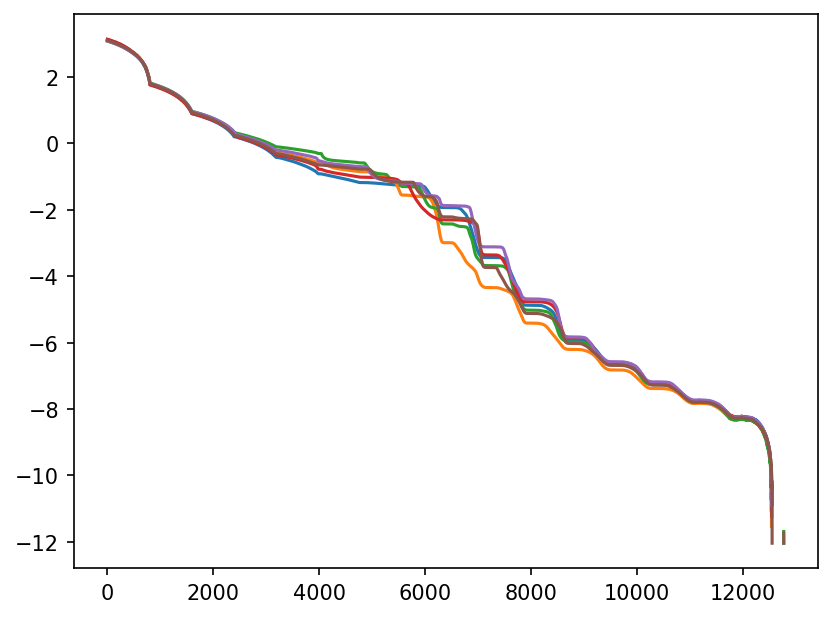

In [13]:
for i in os.listdir(results):
    iter, energy = np.loadtxt(os.path.join(results, i, "E.txt")).T
    err_energy = np.log10(energy - energy[-1])
    plt.plot(iter, err_energy)
plt.show()

## Energy

100%|██████████| 6/6 [00:00<00:00, 131.74it/s]
/tmp/ipykernel_118456/4251900274.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()
/tmp/ipykernel_118456/4251900274.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()
/tmp/ipykernel_118456/4251900274.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend()


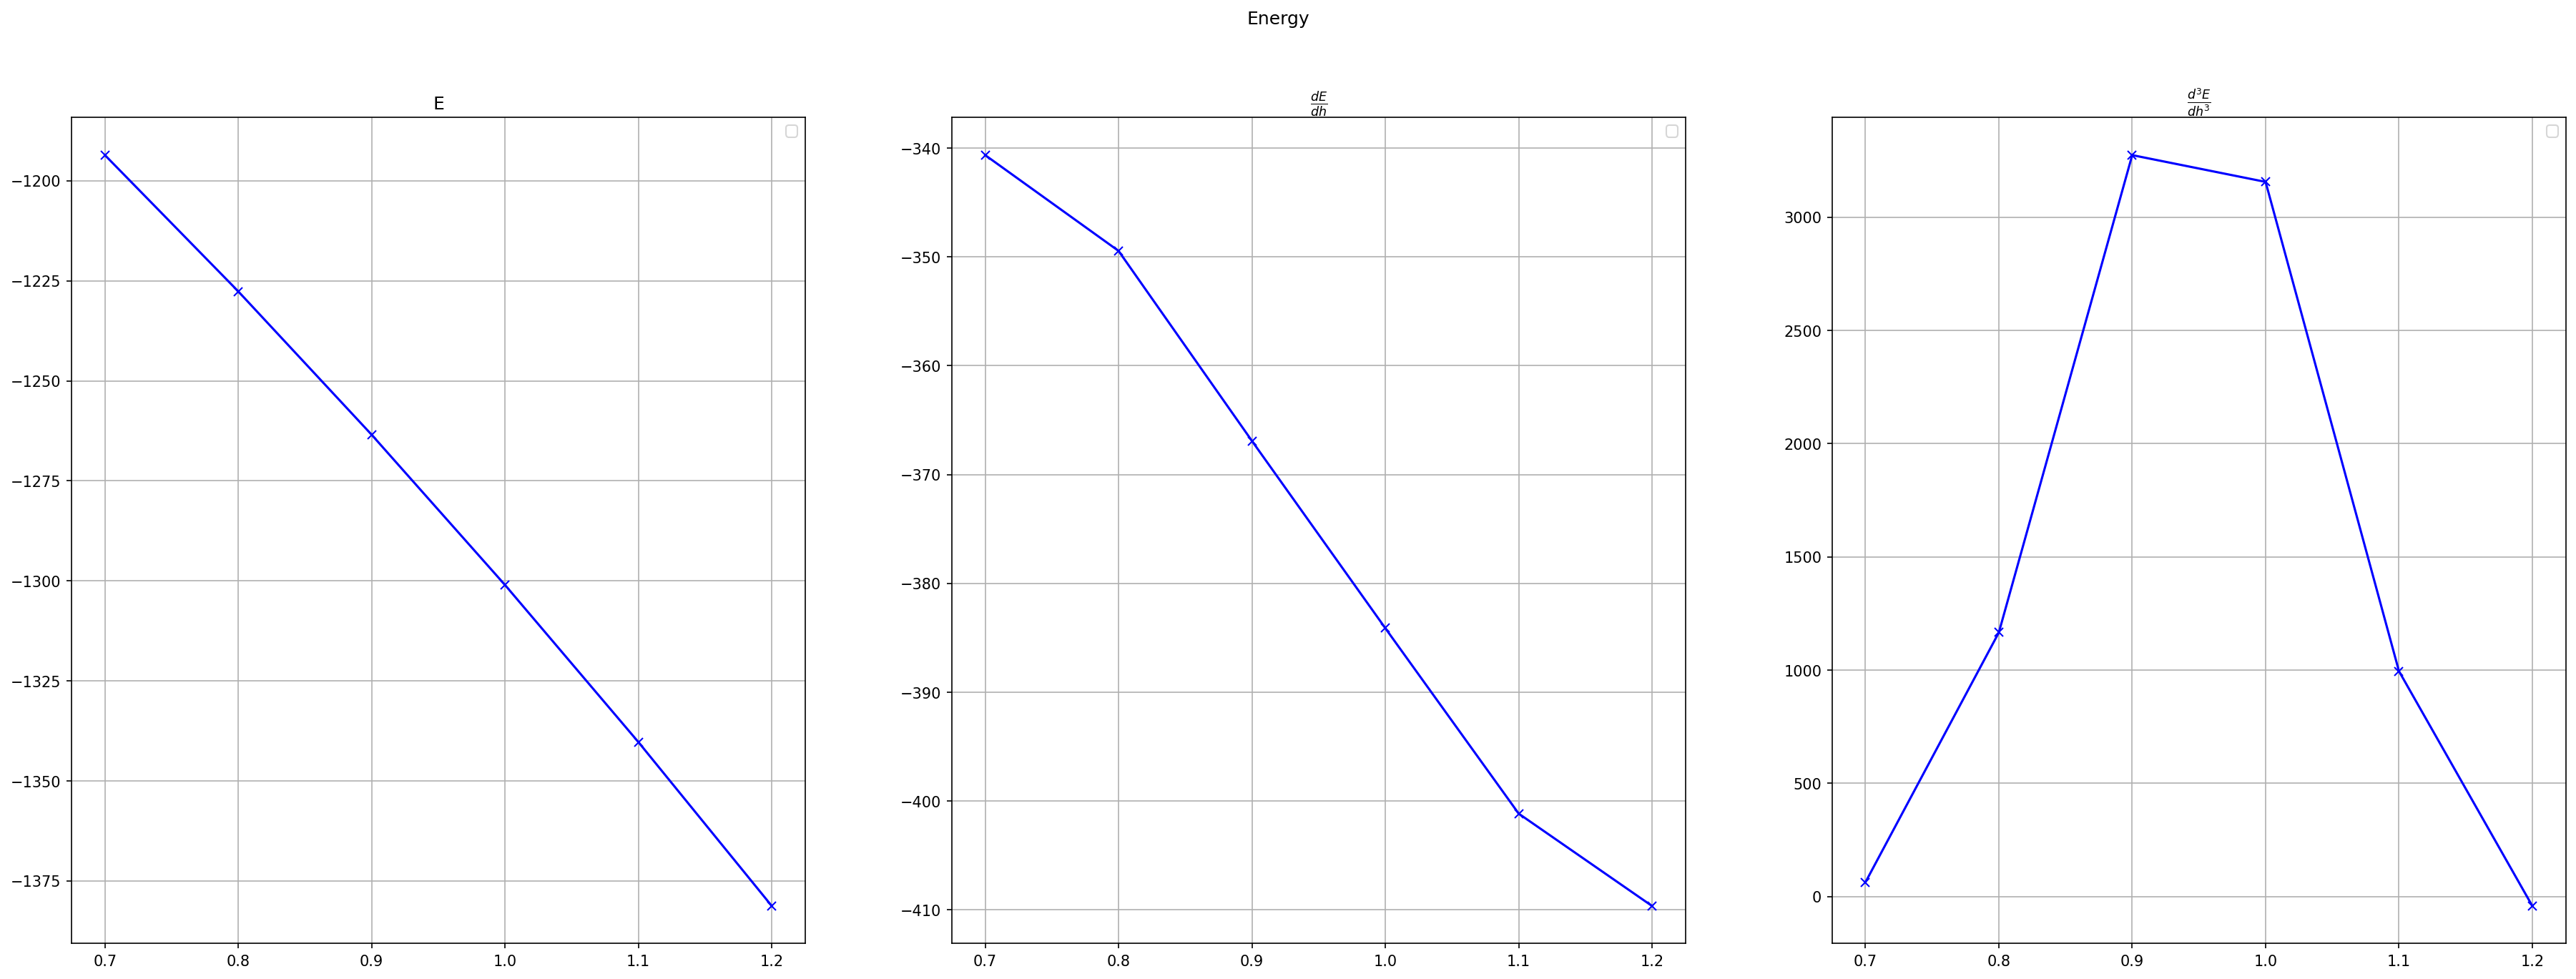

In [14]:
h = [0.5]
slices = [1]
color = ["blue", "red", "green"]

fig, ax = plt.subplots(1, 3, figsize=(30, 10))

# look for energy kink
def find_energy(h, results):
    hs = []
    ks = []
    E = []
    
    for i in tqdm(sorted(os.listdir(results))):
        loc = os.path.join(results, i)
        h, k = i.split("_")
        h = h[1:]
        _, energy = np.loadtxt(os.path.join(loc, "E.txt")).T
            
        E.append(energy[-1])
        hs.append(float(h))
        ks.append(float(k))
    params = np.array([ks, hs])
    return params, E

fig.suptitle("Energy")
for hx, slice, cor in zip(h, slices, color):
    params, E = find_energy(hx, results)
    h, k= params
    dE_dparam = np.gradient(E, k)
    d2E_dparam2 = np.gradient(dE_dparam, k)
    d3E_dparam3 = np.gradient(d2E_dparam2, k)
    d4E_dparam4 = np.gradient(d3E_dparam3, k)
    ax[0].plot(k, E, marker='x', c=cor)
    ax[1].plot(k, dE_dparam, marker='x', c=cor)
    ax[2].plot(k, d4E_dparam4, marker='x', c=cor)
    ax[0].set_title("E")
    ax[1].set_title(r"$\frac{dE}{dh}$")
    ax[2].set_title(r"$\frac{d^3E}{dh^3}$")

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[0].grid()
ax[1].grid()
ax[2].grid()
plt.show()

## Magnetization Profile

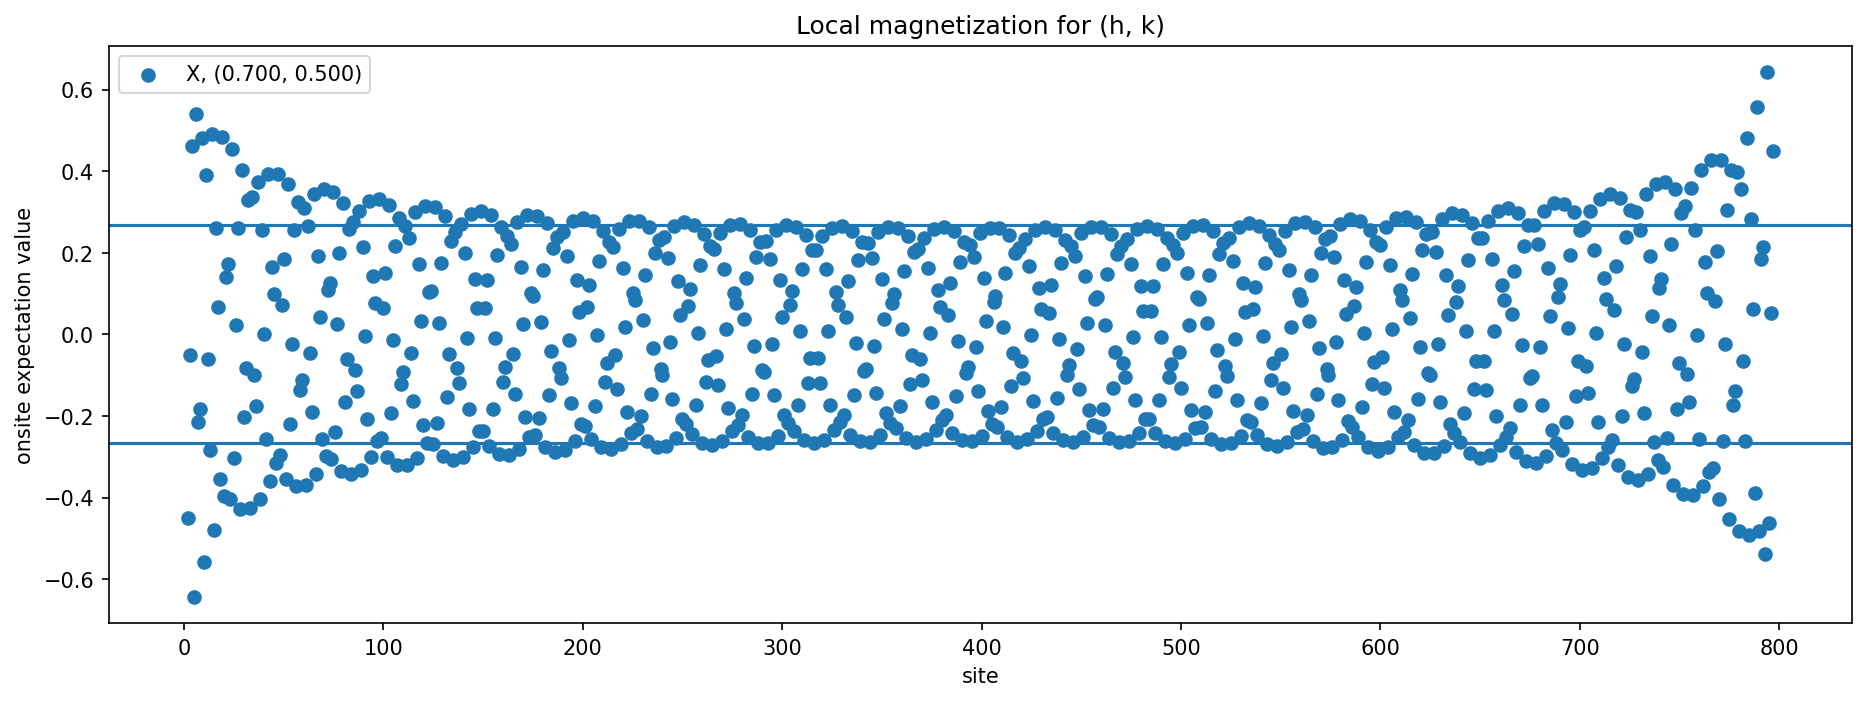

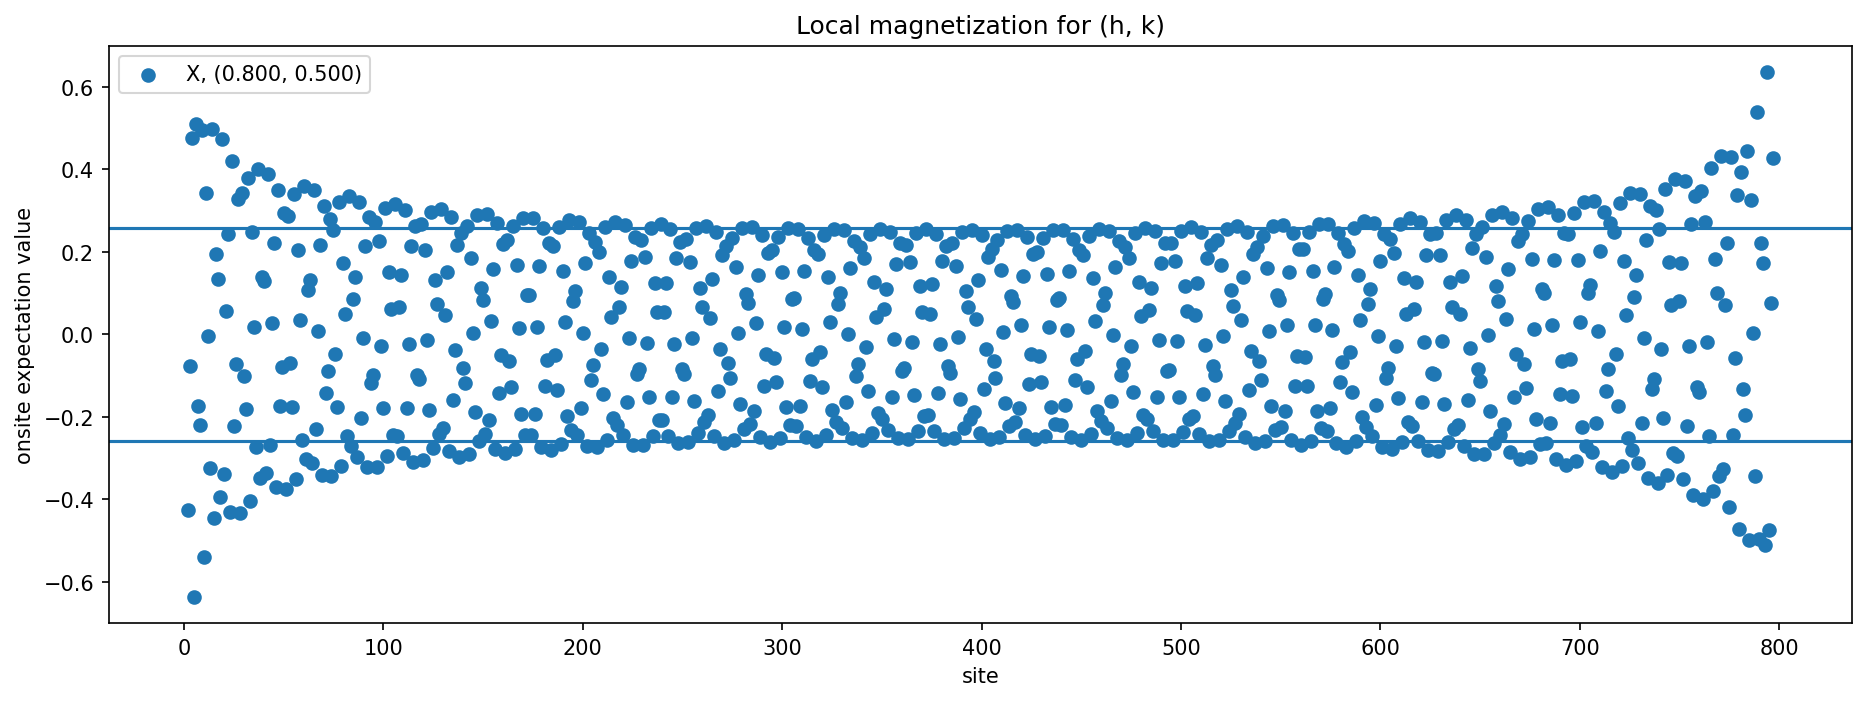

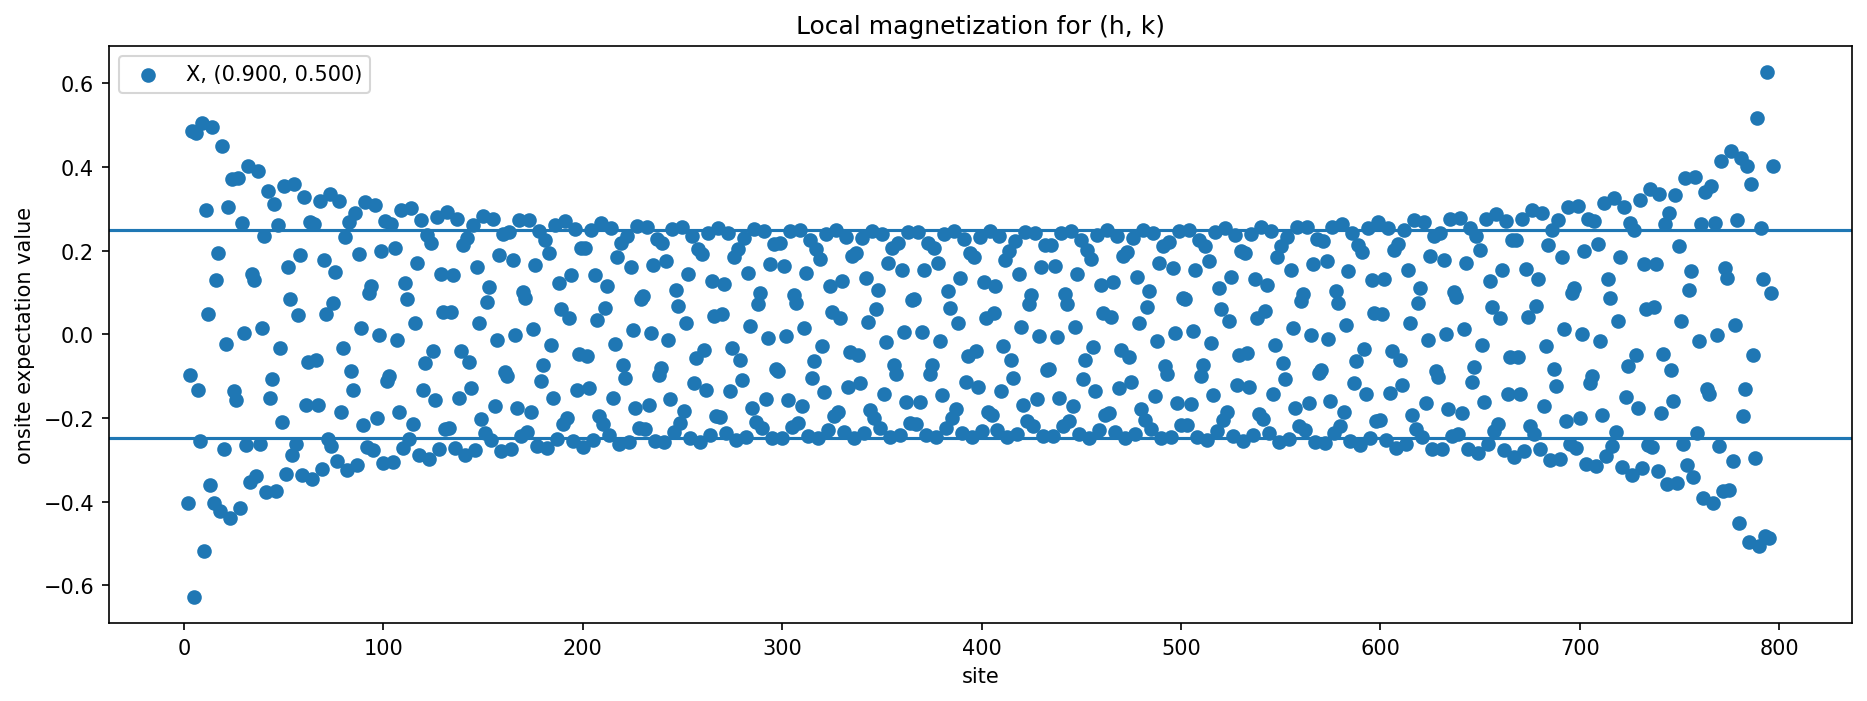

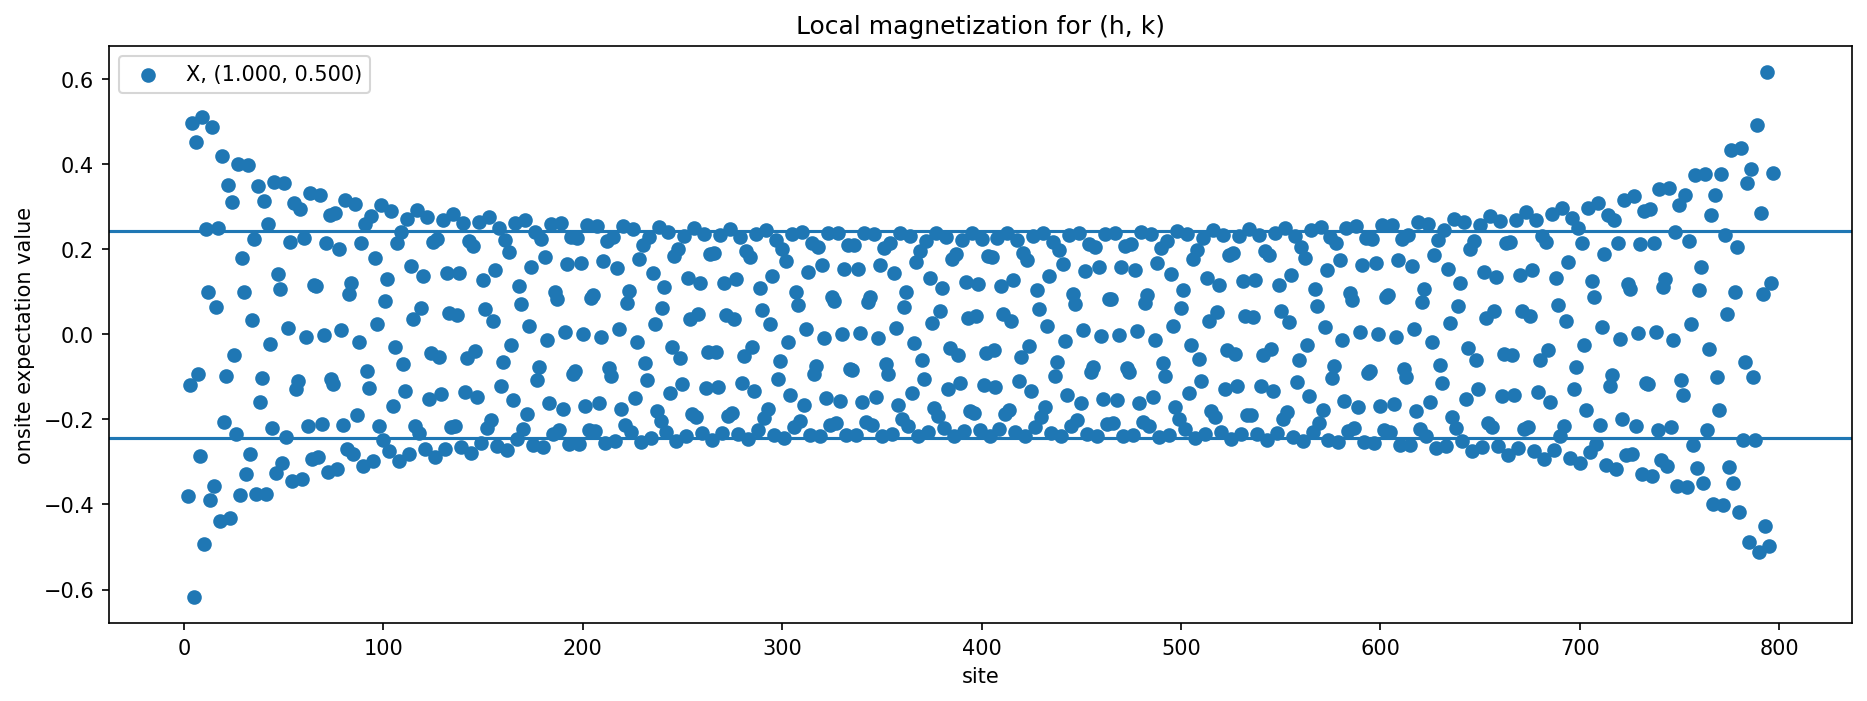

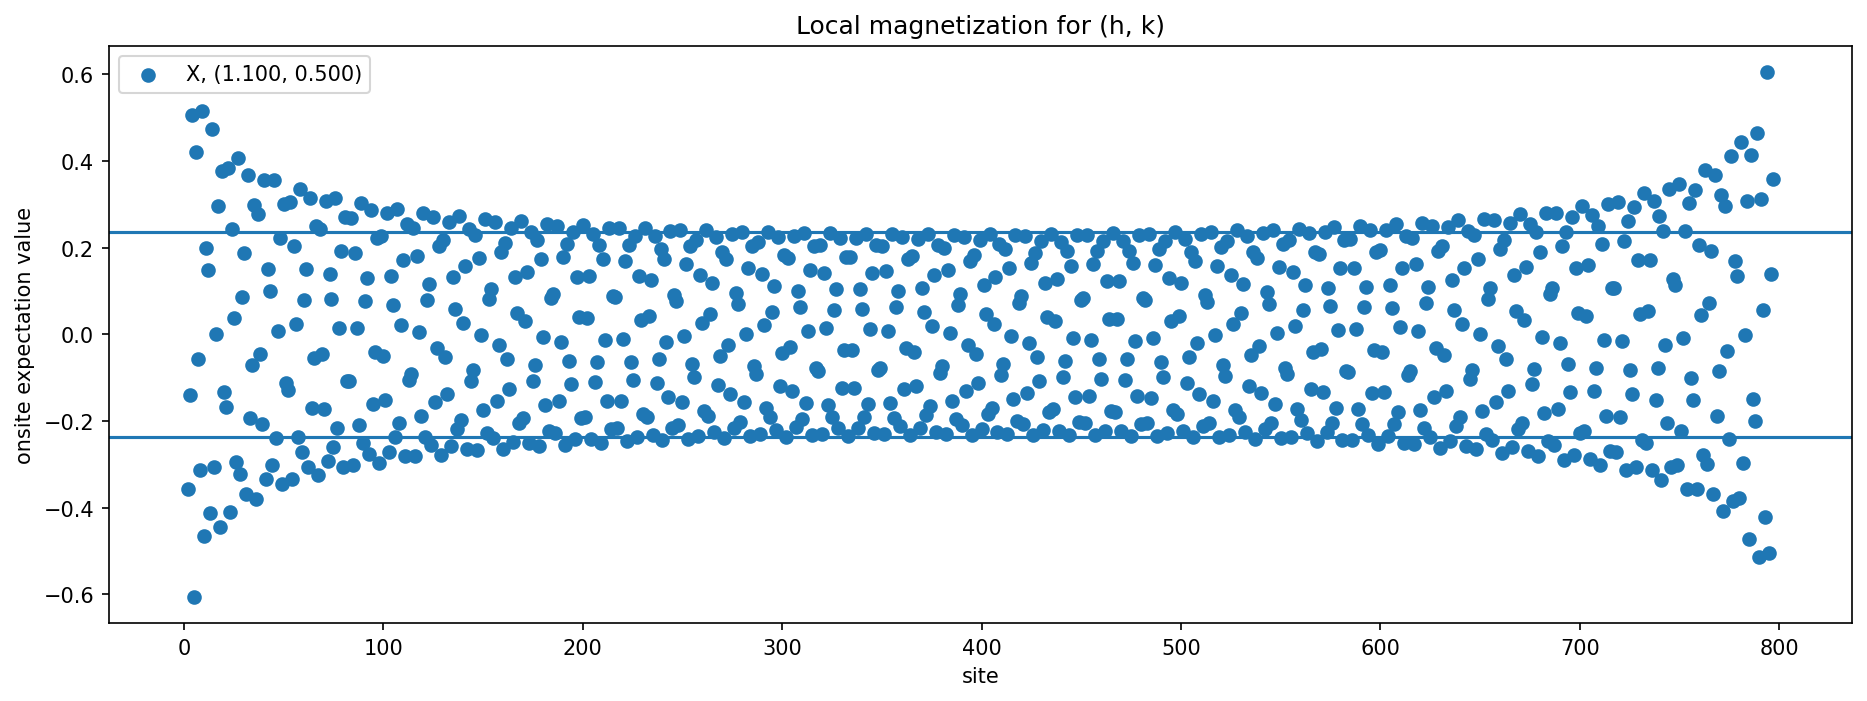

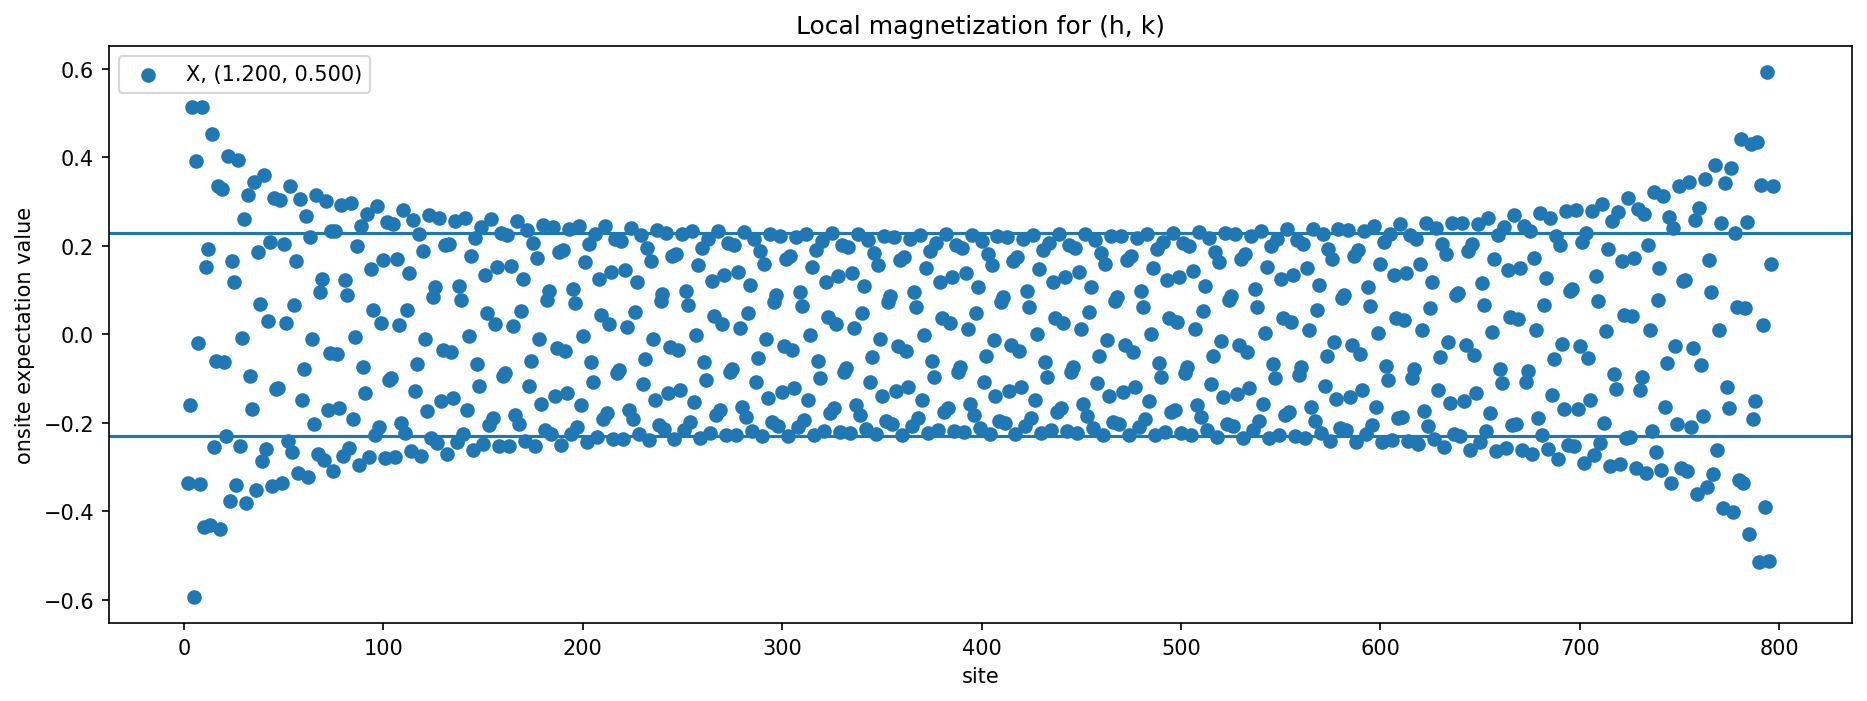

In [19]:
Z = []
par = []
amplitudes = []
# onsite expectation values
for i in sorted(os.listdir(results)):
    loc = os.path.join(results, i)
    k = i.split("_")[-1]
    h = i.split("_")[0][1:]

    h_dual = f"{1/float(h):.3f}"
    k_dual = f"{float(k)/float(h):.3f}"
    results_dual = results+"_dual"

    h_dual = h 
    k_dual = k 
    results_dual = results 

    loc_dual = os.path.join(results_dual, "h"+h_dual+"_"+k_dual)
    par.append(h)

    x, X = np.loadtxt(os.path.join(loc, "X.txt")).T
    A = np.max(X[(3*L//8):(5*L//8)]) - np.min(X[(3*L//8):(5*L//8)])
    cut =  2

    plt.figure(figsize=(15, 5))
    plt.axhline(np.max(X[(3*L//8):(5*L//8)]))
    plt.axhline(np.min(X[(3*L//8):(5*L//8)]))
    plt.scatter(x[cut:-cut], X[cut:-cut], marker='o', label=f"X, ({h}, {k})")
    epsilon = 0.05
    # plt.ylim(-(1+epsilon), (1+epsilon))
    plt.title(f"Local magnetization for (h, k)")
    plt.xlabel("site")
    plt.ylabel("onsite expectation value")
    plt.legend()
    plt.show()
    amplitudes.append(A)

# plt.scatter(par, Z)

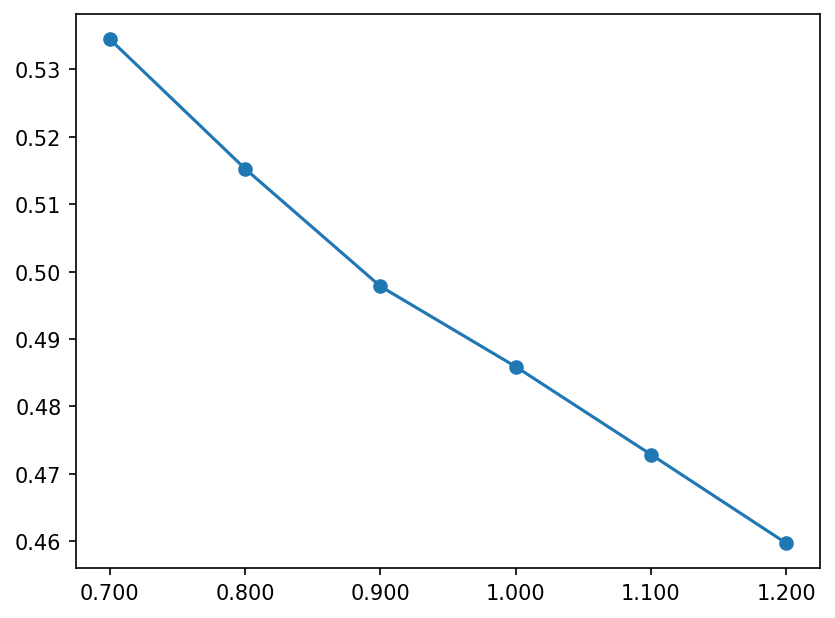

In [20]:
plt.plot(par, np.array(amplitudes), marker='o')
# plt.loglog()

## Duality Check

In [ ]:
for file in sorted(os.listdir(results)):
    h, k = file.split("_")
    h = h[1:]

    h_dual = 1 / float(h)
    k_dual = float(k) / float(h)
    i_dual = f"h{h_dual:.3f}_{k_dual:.3f}"
    print(i_dual)

    loc = os.path.join(results, file)
    loc_dual = os.path.join(results_dual, i_dual)

    x, Z = np.loadtxt(os.path.join(loc, "Z.txt")).T 
    if not os.path.exists(os.path.join(loc_dual, "XX.txt")):
        continue
    y, XX = np.loadtxt(os.path.join(loc_dual, "XX.txt")).T

    cut = L//4
    XX = XX[cut:-cut]
    Z = Z[cut:-cut]
    
    # Remove the mean (background value)
    Z_centered = Z - np.mean(Z)
    XX_centered = XX - np.mean(XX)

    # Rescale XX to match amplitude
    A = np.max(Z) - np.min(Z)
    A2 = np.max(XX) - np.min(XX)

    scale_factor = A/A2
    XX_rescaled =  XX_centered * scale_factor

    from scipy.signal import correlate

    # Normalize (important for unbiased shift detection)
    Z_norm = Z_centered / np.linalg.norm(Z_centered)
    XX_norm = XX_rescaled / np.linalg.norm(XX_rescaled)

    # Full cross-correlation
    corr = correlate(XX_norm, Z_norm, mode='full')

    # Compute corresponding lag values
    lags = np.arange(-len(Z_norm) + 1, len(Z_norm))

    # Best integer shift
    phi = lags[np.argmax(corr)]

    XX_shifted = XX_rescaled

    plt.figure(figsize=(15,5))
    plt.scatter(x[cut:-cut], Z_centered, marker="o",
            label=r"$\sigma_i^Z$ (centered)"+f"{h_dual}, {k_dual}")

    plt.scatter(y[cut:-cut]+2.5, XX_shifted, marker="o", alpha=0.6,
         label=r"$\sigma_i^X\sigma_{i+1}^X$ (rescaled, shifted)"+f"{h}, {k}")   
    plt.grid()
    plt.legend()
    plt.xlabel("Lattice site")
    plt.ylabel("Centered observables")
    plt.title(f"Duality check for (h, k) = ({h}, {k}), scale factor = {scale_factor:.3f}")
    plt.show()


h2.000_0.200
h2.000_0.240
h2.000_0.280
h2.000_0.320
h2.000_0.360
h2.000_0.400
h2.000_0.440
h2.000_0.480
h2.000_0.520
h2.000_0.560
h2.000_0.600
h2.000_0.640
h2.000_0.680
h2.000_0.720
h2.000_0.760
h2.000_0.800


0.5739224194299216


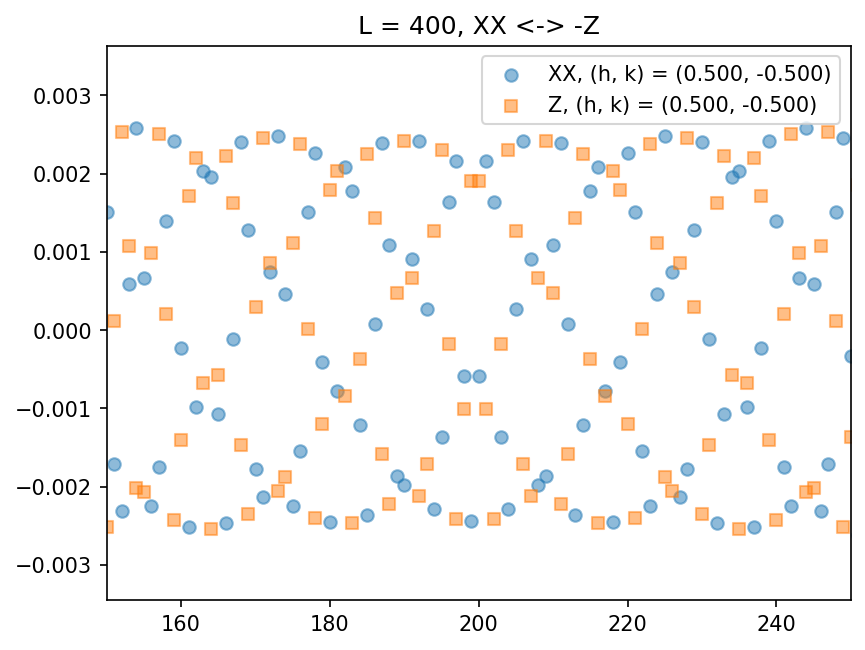

0.5509220138108806


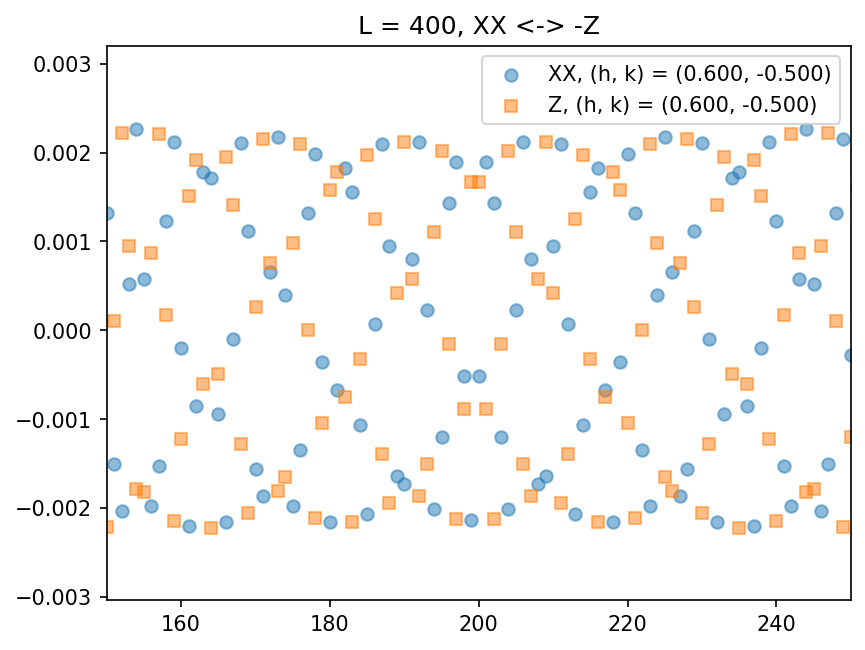

0.5270492438301235


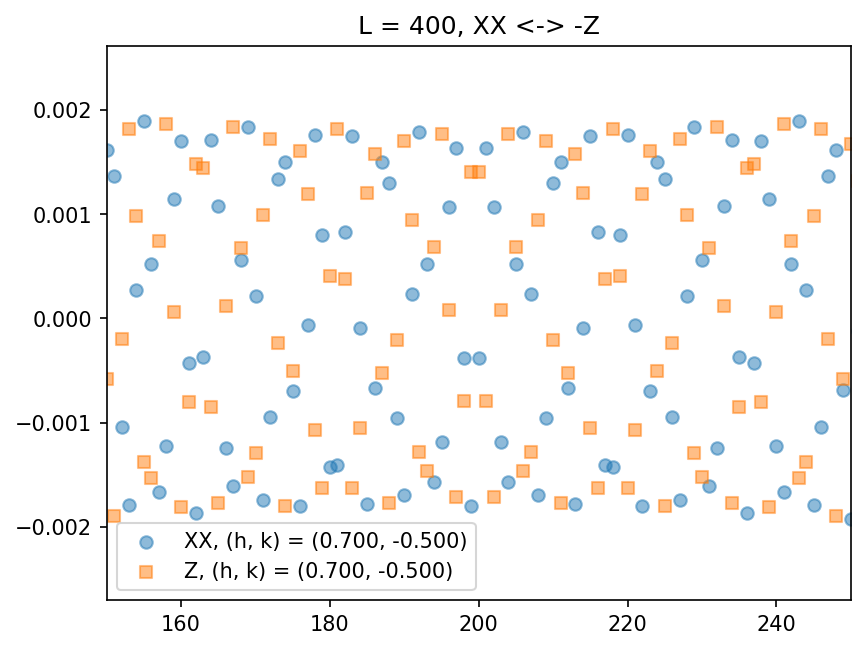

0.5123005995567236


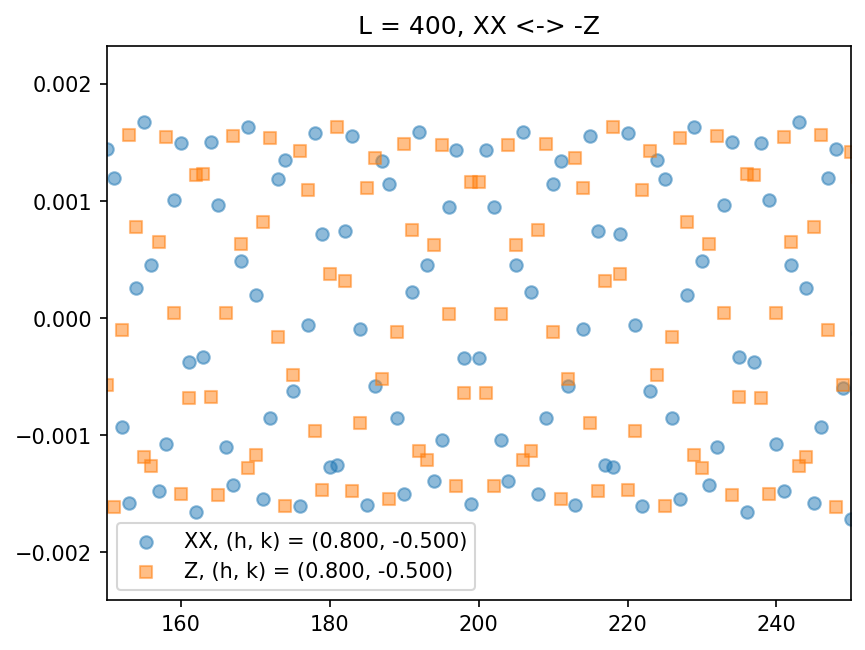

0.4688653836053948


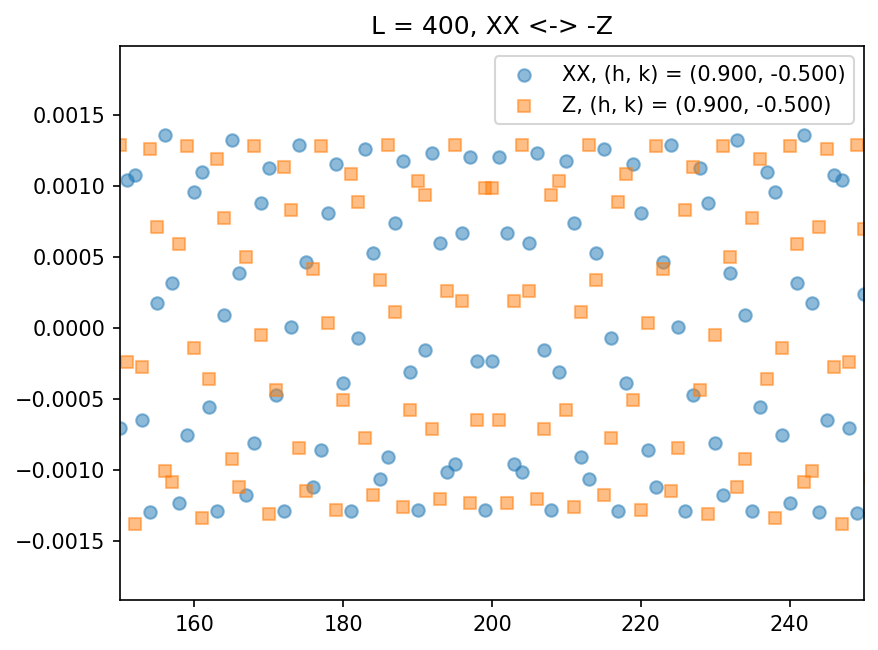

0.2638004072448663


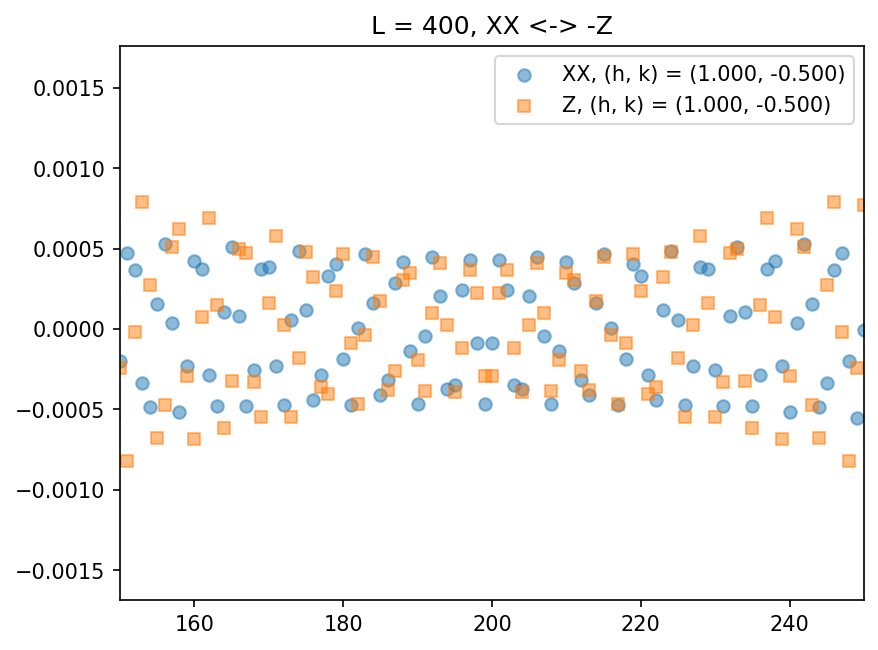

0.39732568071134455


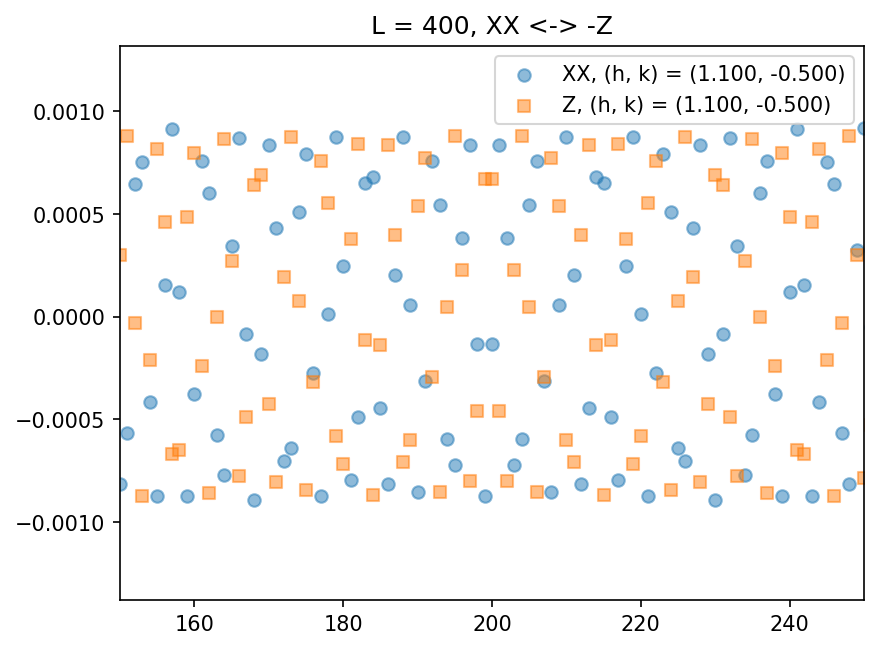

0.38425322232170545


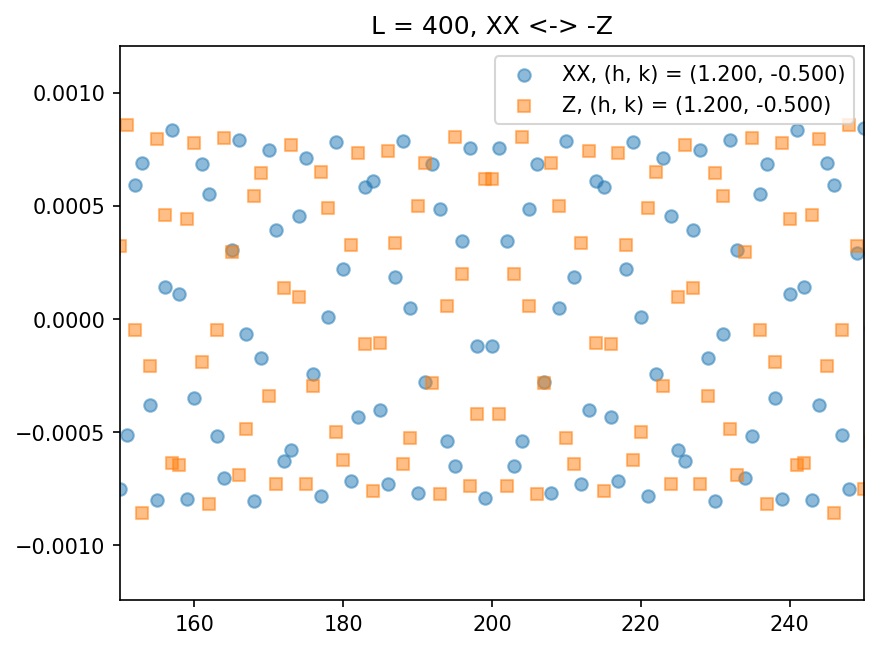

0.34193647745084976


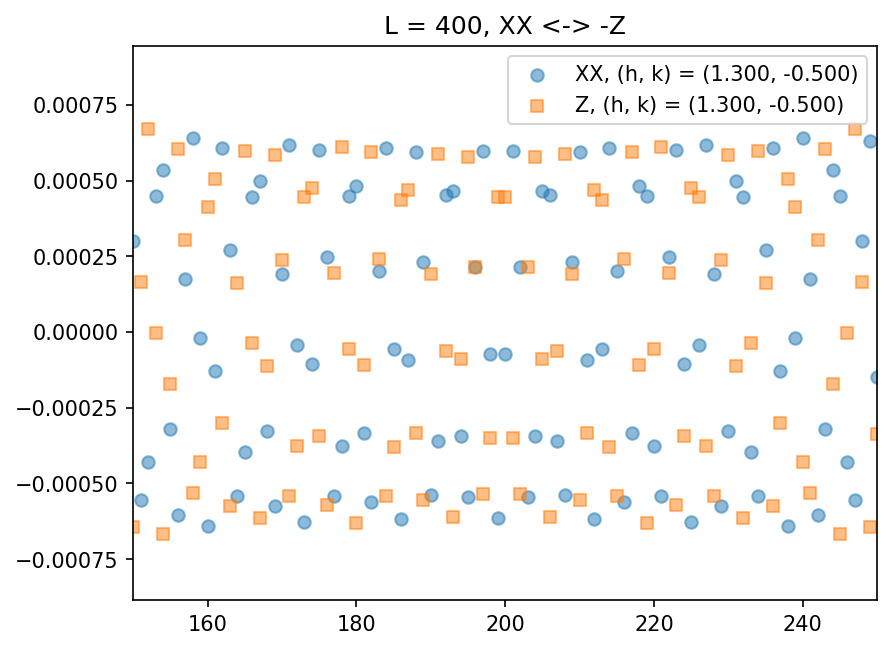

0.3291280116909468


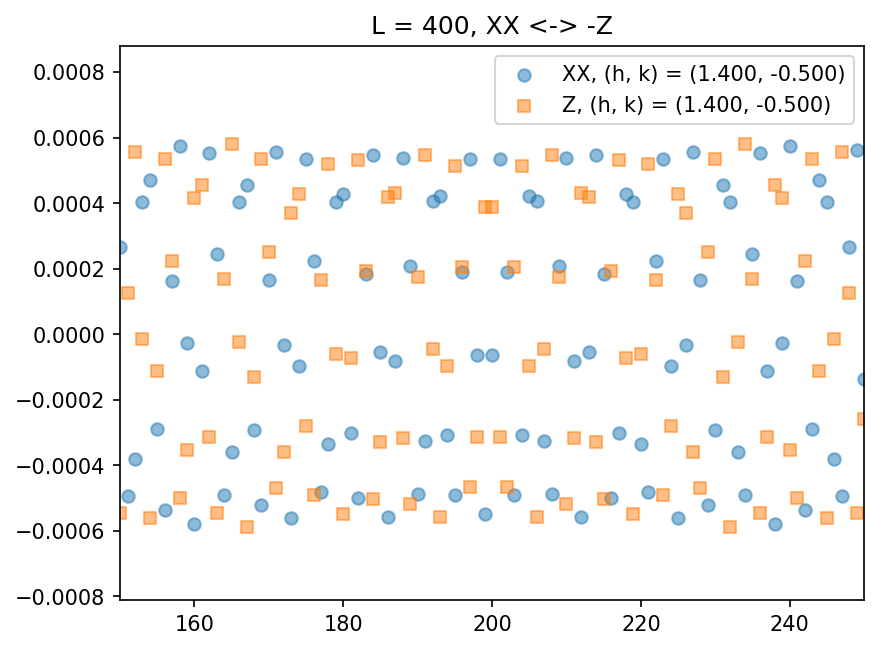

0.3317710908645113


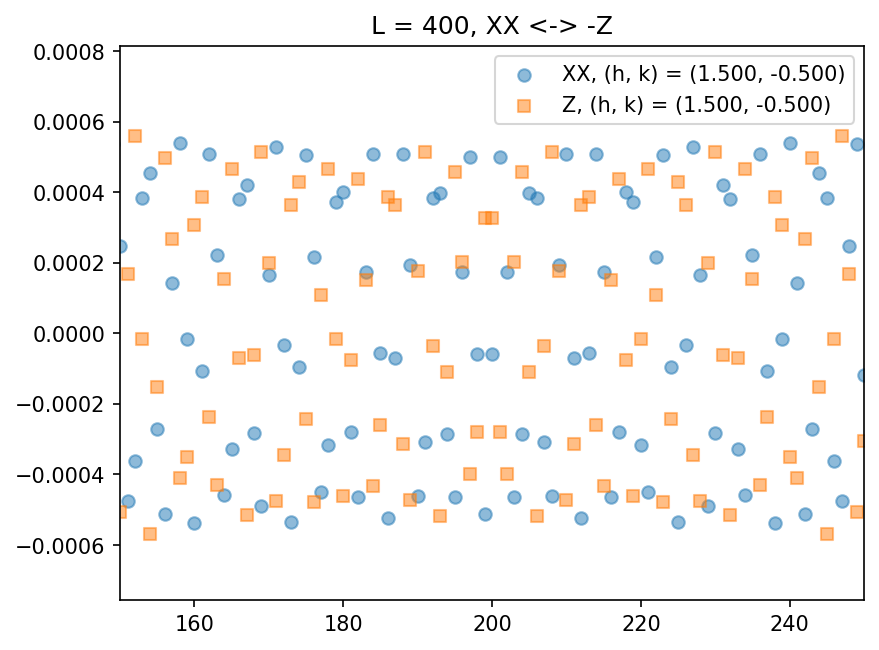

In [ ]:
for i in os.listdir(results):
    h, k = i.split("_")
    h = h[1:]
    if float(h) == 0.0:
        continue
    h_dual = 1 / float(h)
    k_dual = float(k) / float(h)
    i_dual = f"h{h_dual:.3f}_{k_dual:.3f}"

    loc = os.path.join(results, i)
    loc_dual = os.path.join(results_dual, i_dual)

    x, XYZ = np.loadtxt(os.path.join(loc, "XX.txt")).T
    y, YIX = np.loadtxt(os.path.join(loc, "Z.txt")).T
    cut = L//4
    # Remove the mean (background value)
    YIX_centered = YIX[cut:-cut] - np.mean(YIX[cut:-cut])
    XYZ_centered = XYZ[cut:-cut] - np.mean(XYZ[cut:-cut])
    middle = 180
    A = (np.max(YIX[middle:-middle]) - np.min(YIX[middle:-middle])) / (np.max(XYZ[middle:-middle]) - np.min(XYZ[middle:-middle]))
    print(A)
    # # Rescale XX to match amplitude
    scale_factor = (np.std(YIX_centered) / np.std(XYZ_centered))
    XYZ_rescaled =  XYZ_centered 

    plt.scatter(x[cut:-cut], A*XYZ_rescaled, marker="o", alpha=0.5, label=f"XX, (h, k) = ({h}, {k})")
    plt.scatter(y[cut:-cut], YIX_centered, marker="s", alpha=0.5, label=f"Z, (h, k) = ({h}, {k})")
    plt.xlim(150, 250)
    plt.title(f"L = {L}, XX <-> -Z")
    plt.legend()
    plt.show()

    

(h,k)=(0.800,0.500)  best shift = 155


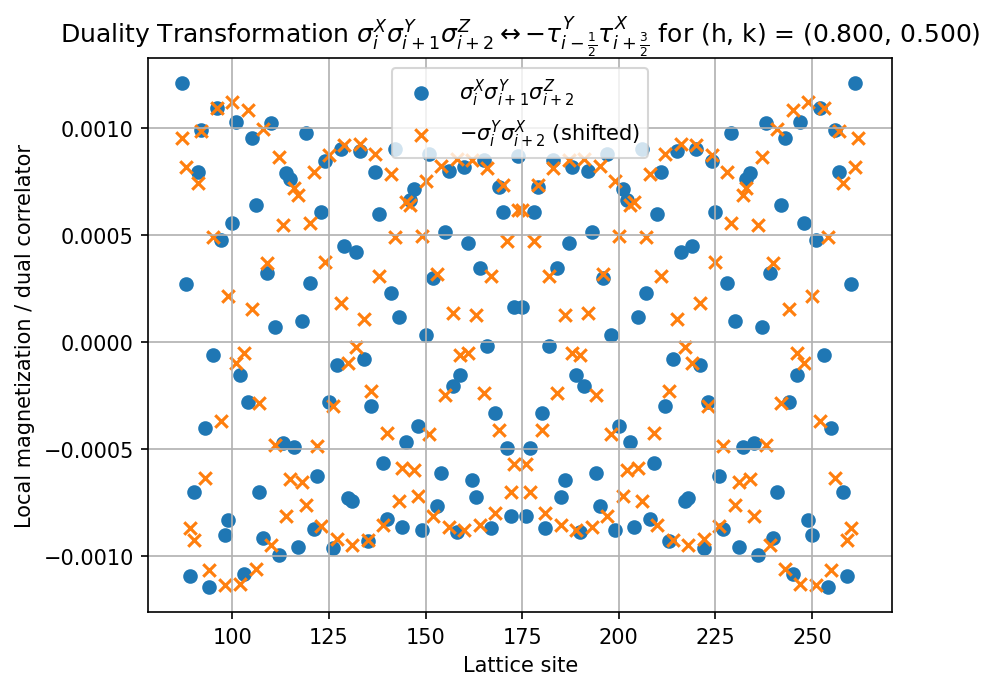

(h,k)=(0.850,0.500)  best shift = -147


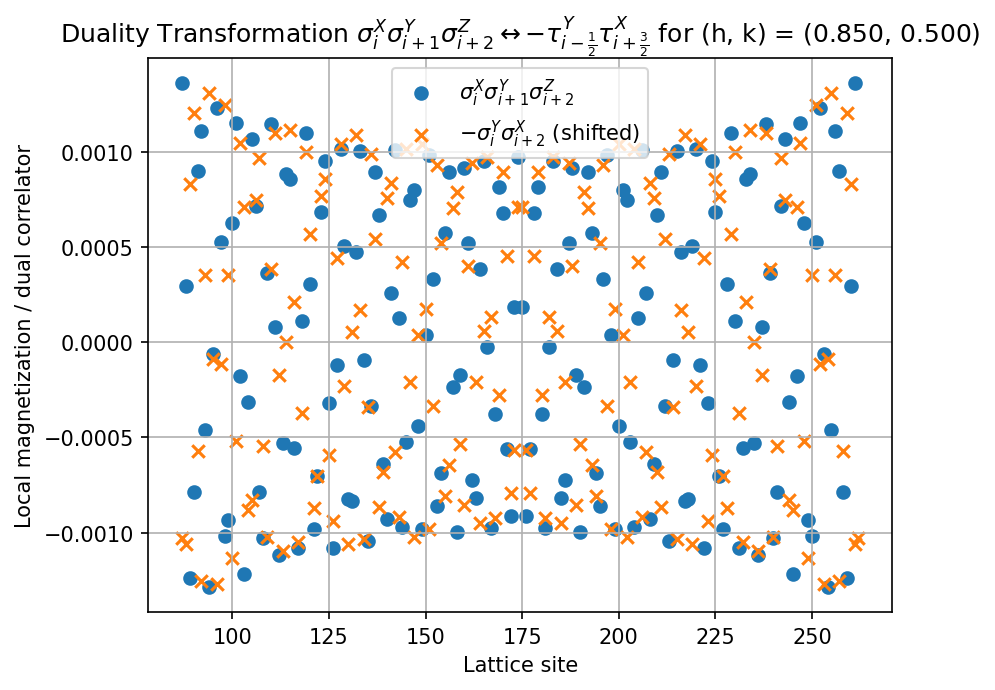

(h,k)=(0.900,0.500)  best shift = -140


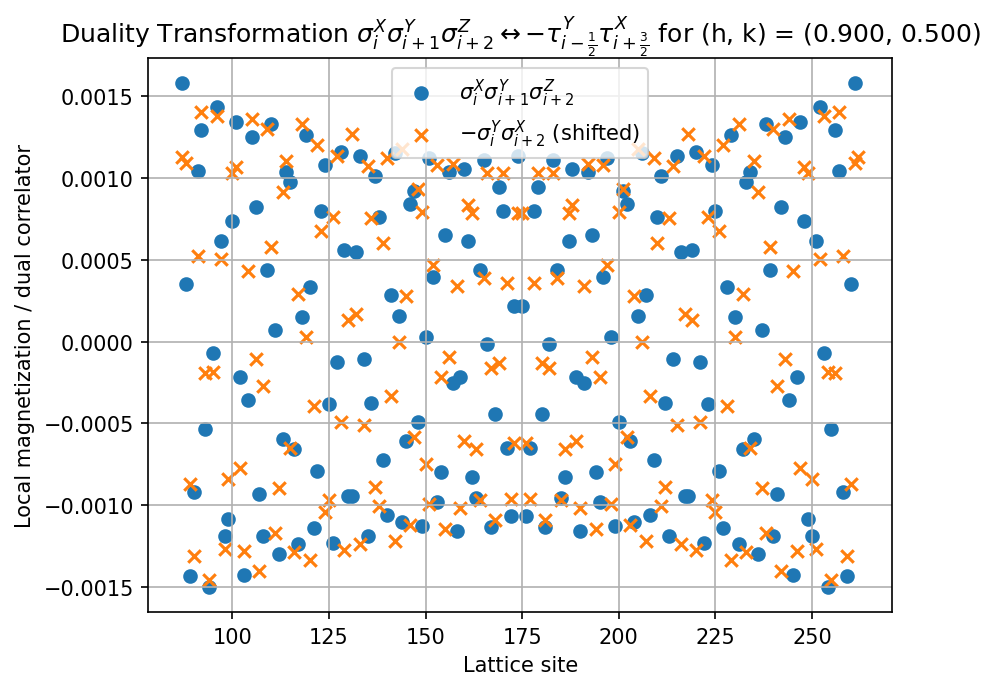

(h,k)=(0.950,0.500)  best shift = 91


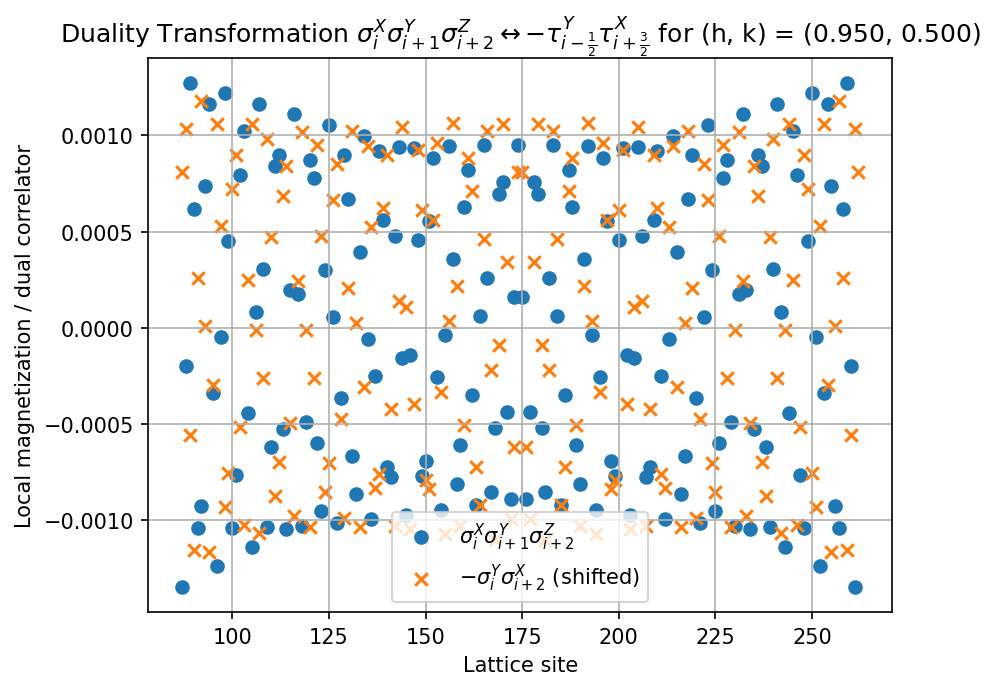

(h,k)=(1.000,0.500)  best shift = 3


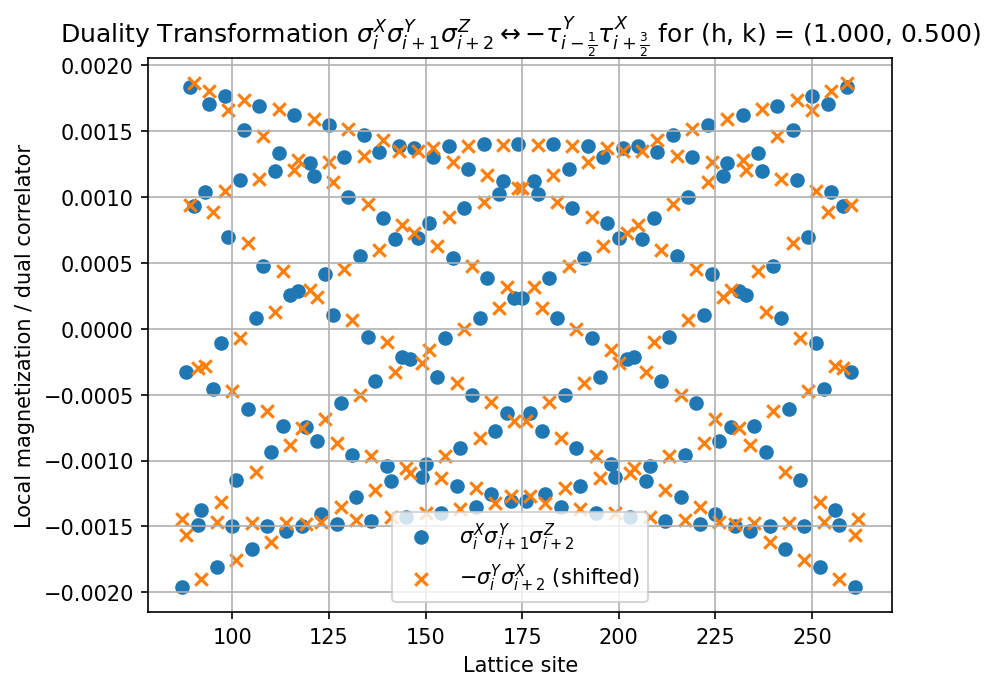

(h,k)=(1.050,0.500)  best shift = -101


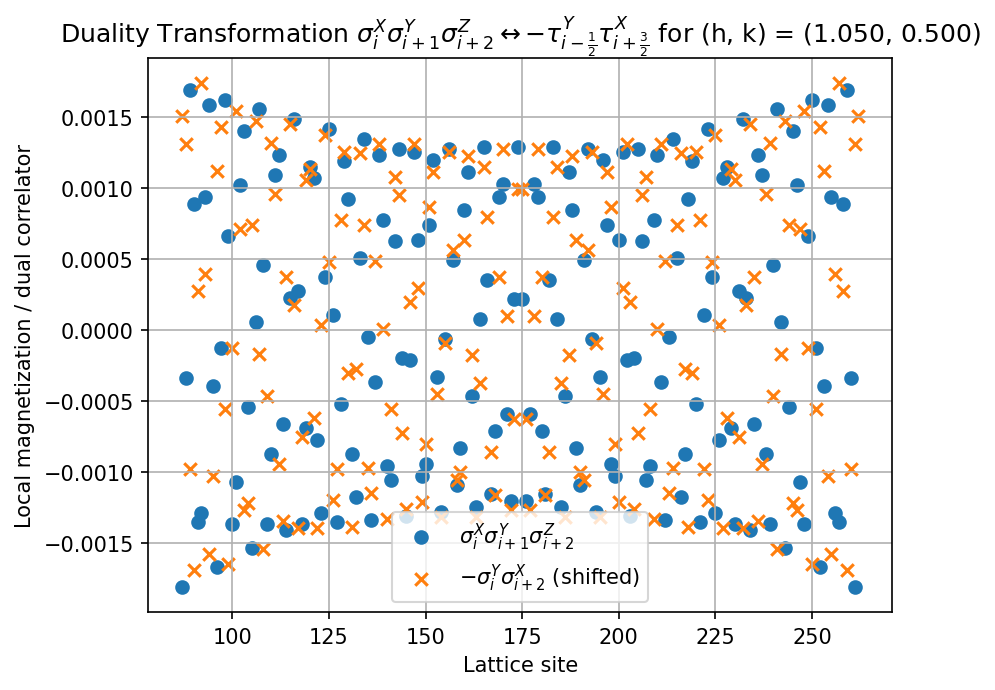

In [ ]:
for i in os.listdir(results):
    h, k = i.split("_")
    h = h[1:]
    if float(h) == 0.0:
        continue
    h_dual = 1 / float(h)
    k_dual = float(k) / float(h)
    i_dual = f"h{h_dual:.3f}_{k_dual:.3f}"

    loc = os.path.join(results, i)
    loc_dual = os.path.join(results_dual, i_dual)

    x, XYZ = np.loadtxt(os.path.join(loc, "XX.txt")).T
    y, YIX = np.loadtxt(os.path.join(loc_dual, "Z.txt")).T

    cut = L // 4
    # Remove the mean (background value)
    YIX_centered = YIX[cut:-cut] - np.mean(YIX[cut:-cut])
    XYZ_centered = XYZ[cut:-cut] - np.mean(XYZ[cut:-cut])

    # # Rescale XX to match amplitude
    scale_factor = (np.std(YIX_centered) / np.std(XYZ_centered))
    XYZ_rescaled =  XYZ_centered * -scale_factor

    from scipy.signal import correlate

    # Normalize (important)
    A = XYZ_rescaled / np.linalg.norm(XYZ_rescaled)
    B = (-YIX_centered) / np.linalg.norm(YIX_centered)

    # Full cross-correlation
    corr = correlate(B, A, mode="full")
    lags = np.arange(-len(A) + 1, len(A))

    # Best integer shift
    phi = lags[np.argmax(corr)]

    print(f"(h,k)=({h},{k})  best shift = {phi}")

    YIX_shifted = np.roll(YIX_centered, 0.5)

    plt.scatter(x[cut:-cut], XYZ_rescaled,
            marker="o",
            label=r"$\sigma_i^X\sigma_{i+1}^Y\sigma_{i+2}^Z$")

    plt.scatter(y[cut:-cut], YIX_shifted,
            marker="x",
            label=r"$-\sigma_{i}^Y\sigma_{i+2}^X$ (shifted)")
    plt.grid()
    plt.legend()
    plt.xlabel("Lattice site")
    plt.ylabel("Local magnetization / dual correlator")
    plt.title(r"Duality Transformation $\sigma_i^X\sigma_{i+1}^Y\sigma_{i+2}^Z \leftrightarrow $" \
    r"$-\tau_{i-\frac{1}{2}}^Y\tau_{i+\frac{3}{2}}^X$"+f" for (h, k) = ({h}, {k})")
    plt.show()
    

## Fitting q and K

Now that we know that we have a LL phase, we start looking for a fit of q and K.

According to bCFT, we expect Friedel Oscillations of a finite size system to follow:
$$\langle \sigma_i \rangle \propto \frac{\cos{(qi + \phi)}}{\left[(N/\pi) \cos{(\pi i/N)}\right]^K}$$

In order to get a good guess for all our parameters, we need to fit in phases - first we fit the envelope, then the oscillations. If we have the full function below:

$$\langle \sigma_i \rangle = A\frac{\cos{(qi + \phi)}}{\left[(N/\pi) \cos{(\pi i/N)}\right]^K} + B$$

We start by fitting for K, which controls the amplitudes via 

  0%|          | 0/6 [00:00<?, ?it/s]

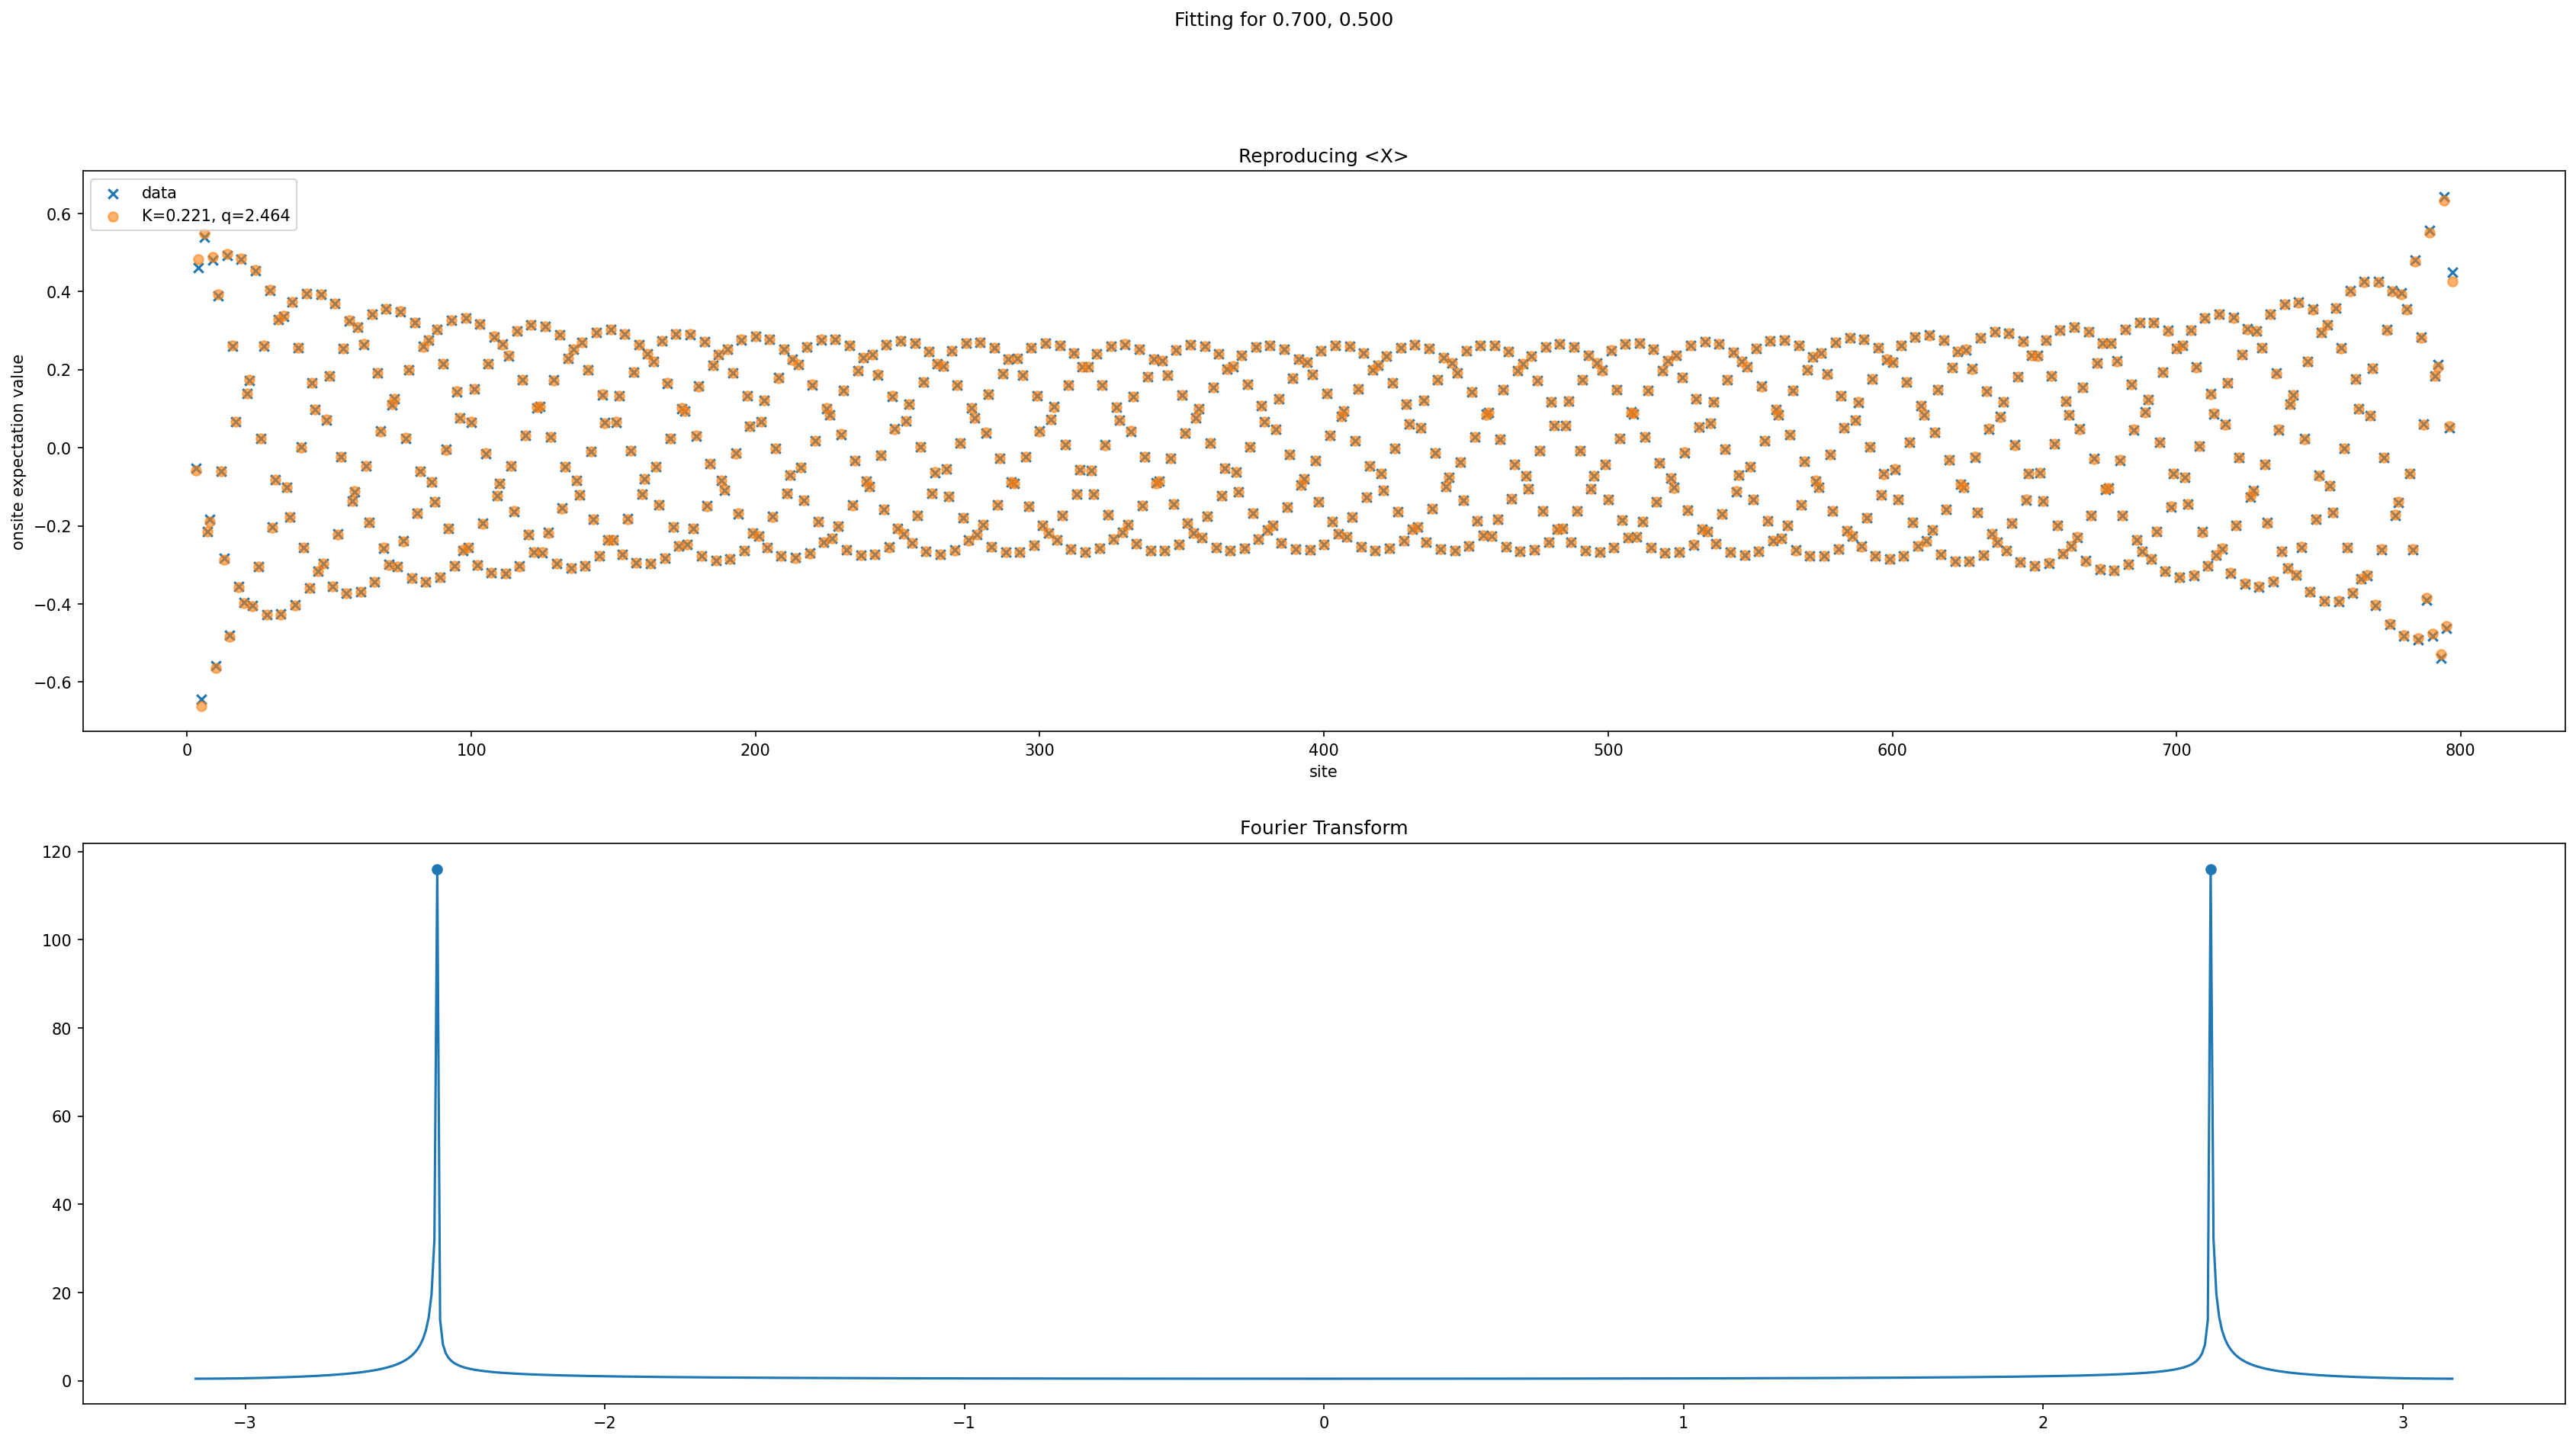

 17%|█▋        | 1/6 [00:00<00:03,  1.42it/s]

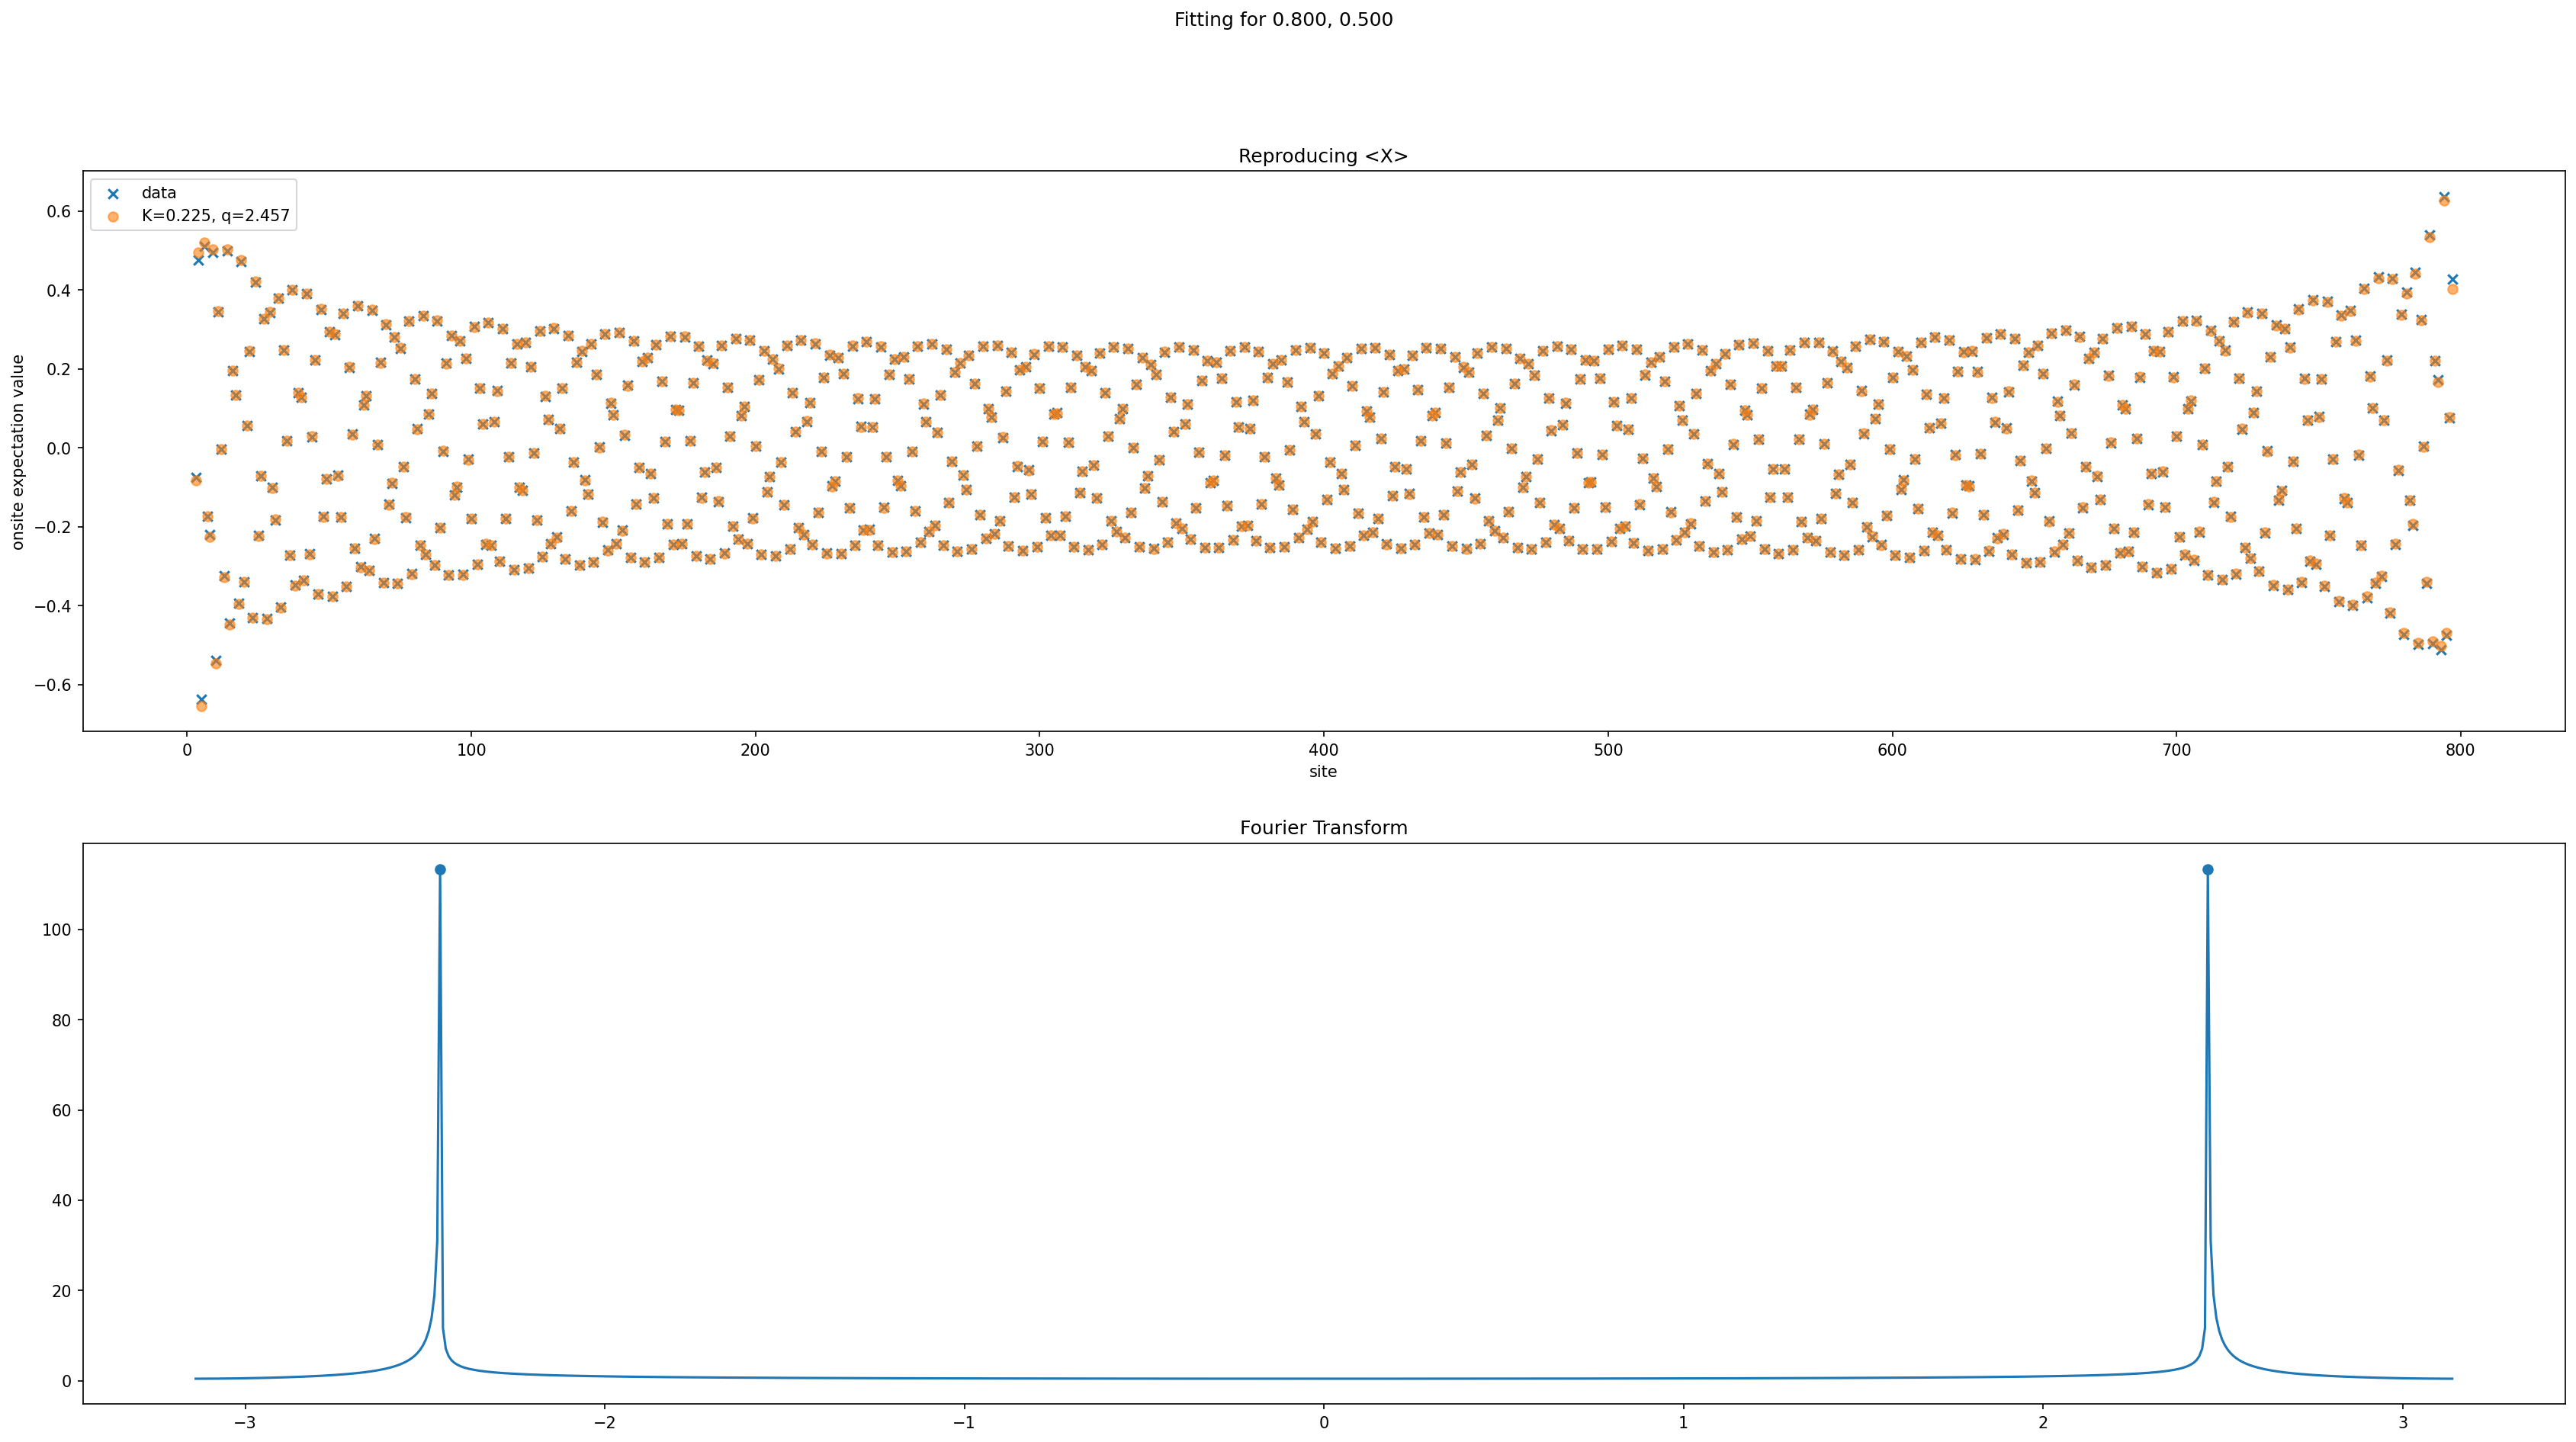

 33%|███▎      | 2/6 [00:01<00:02,  1.41it/s]

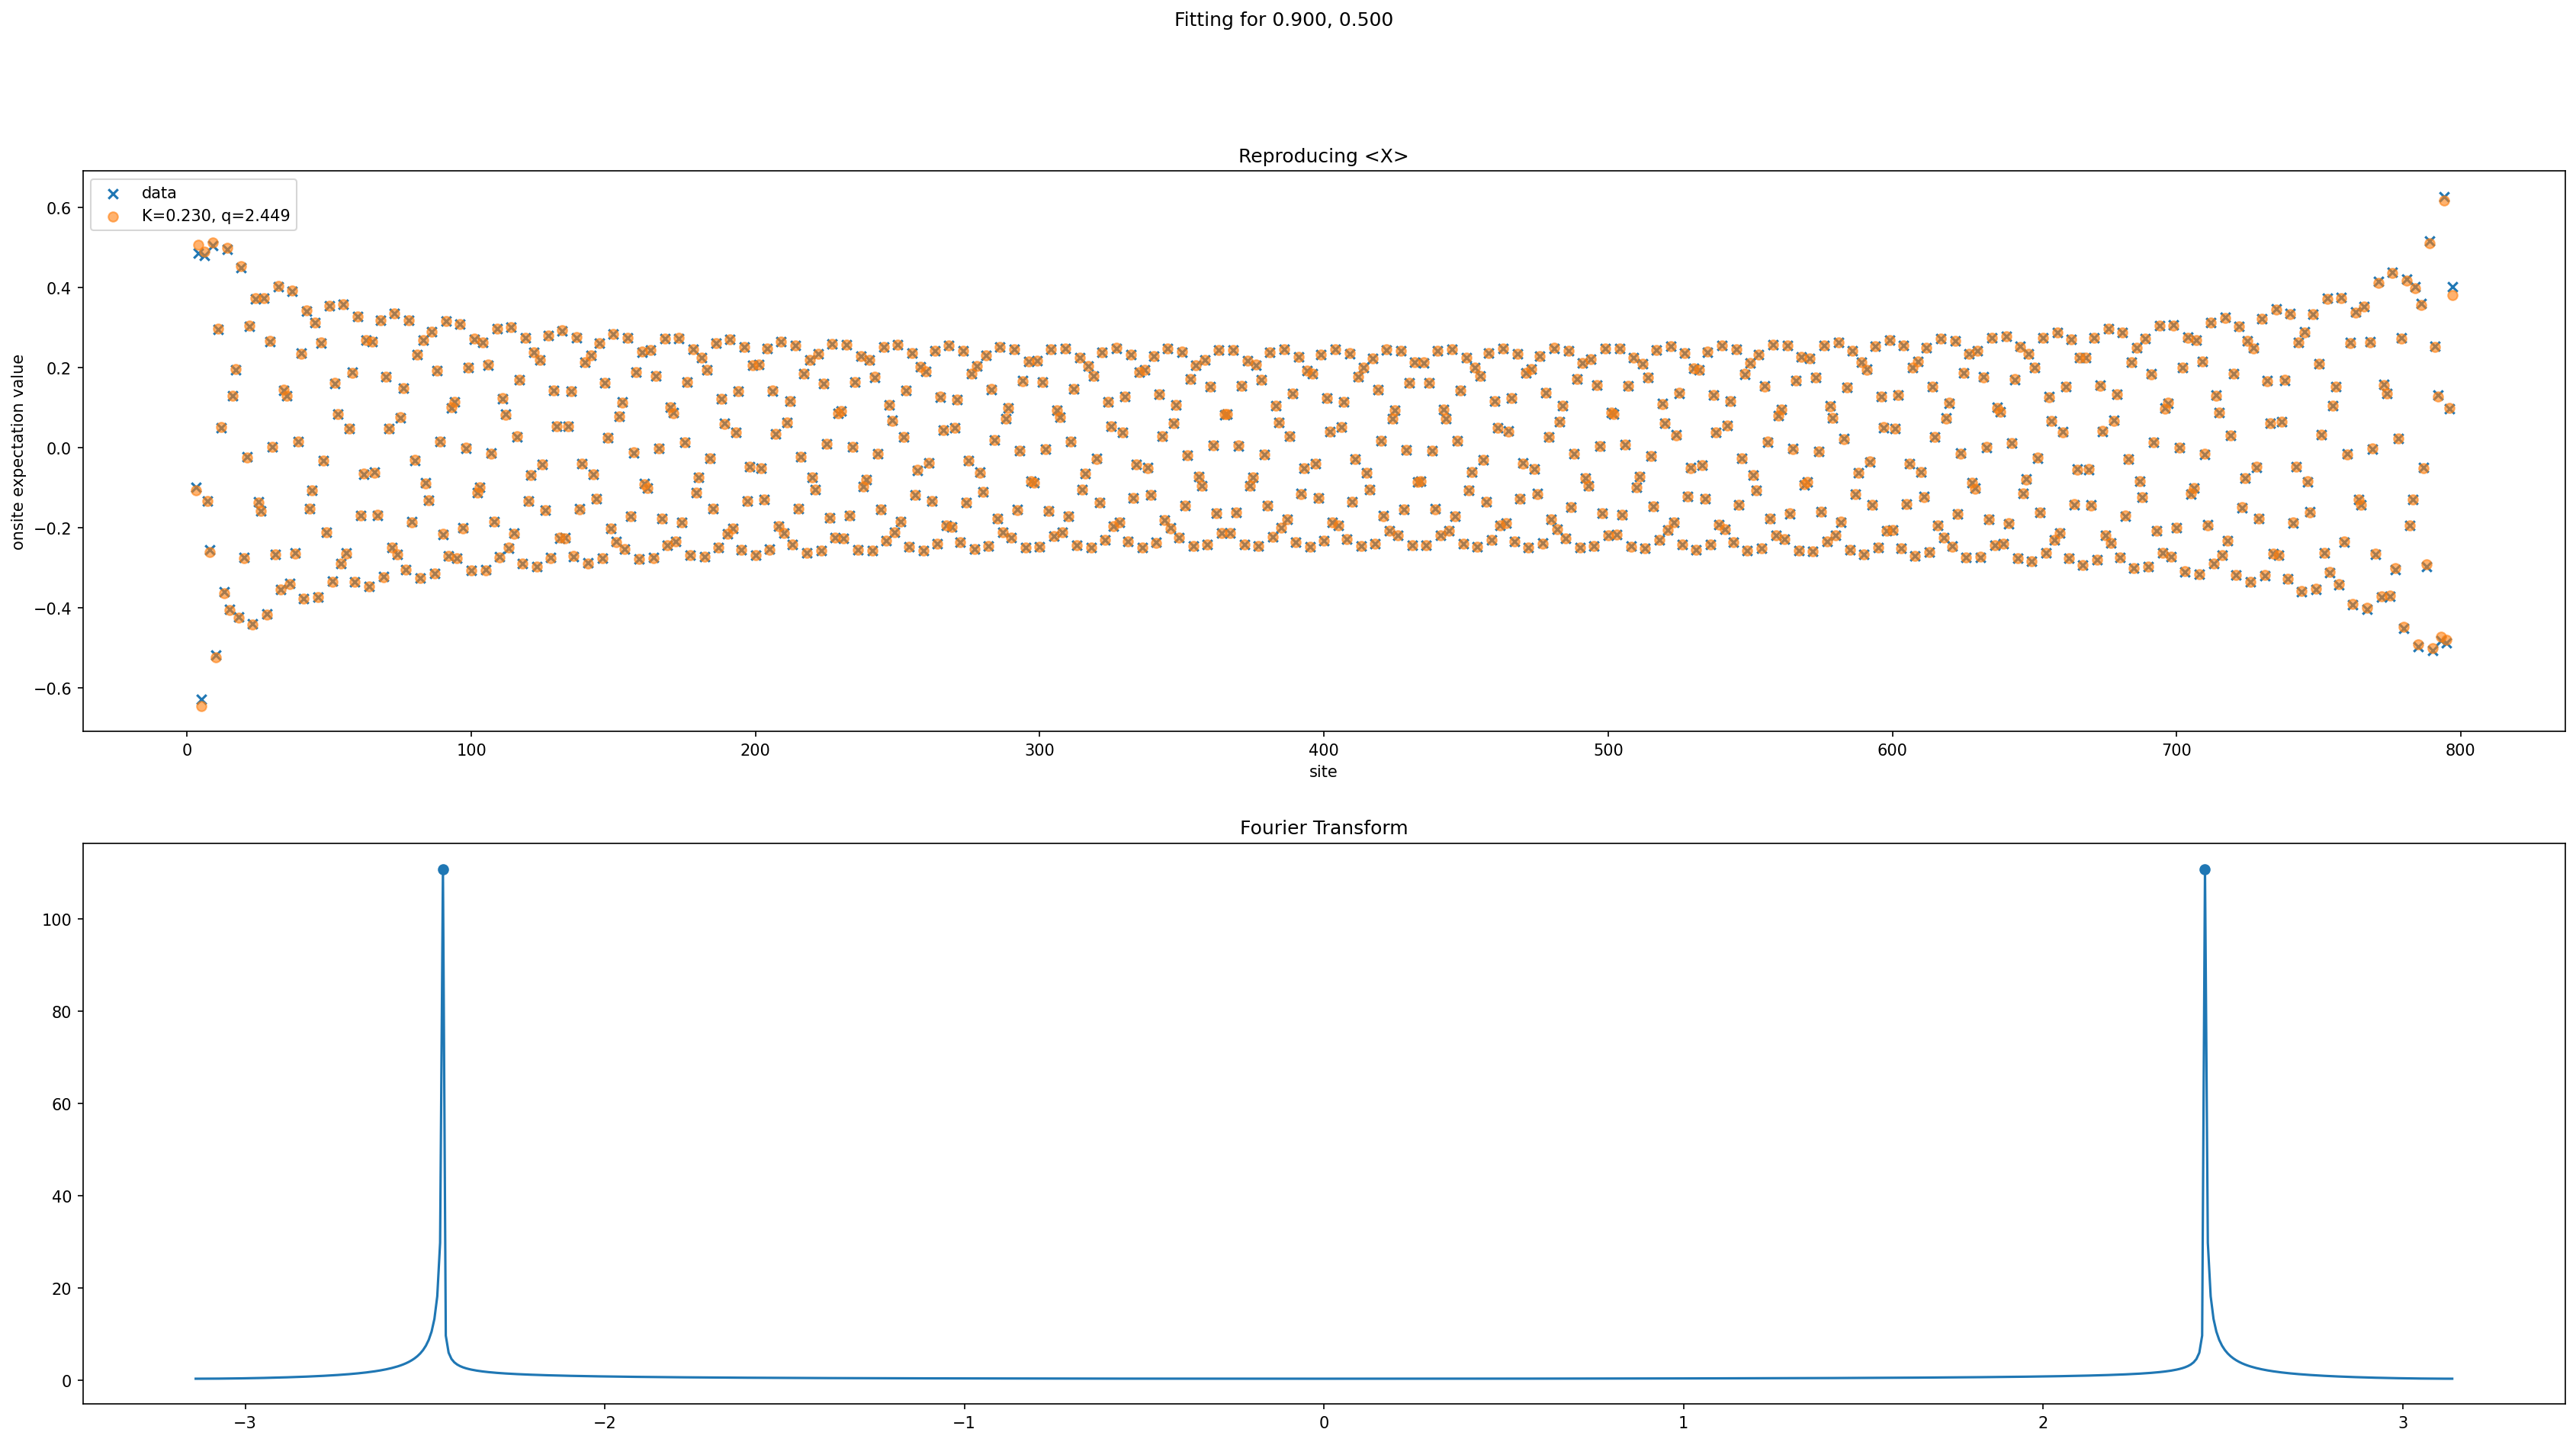

 50%|█████     | 3/6 [00:02<00:02,  1.31it/s]

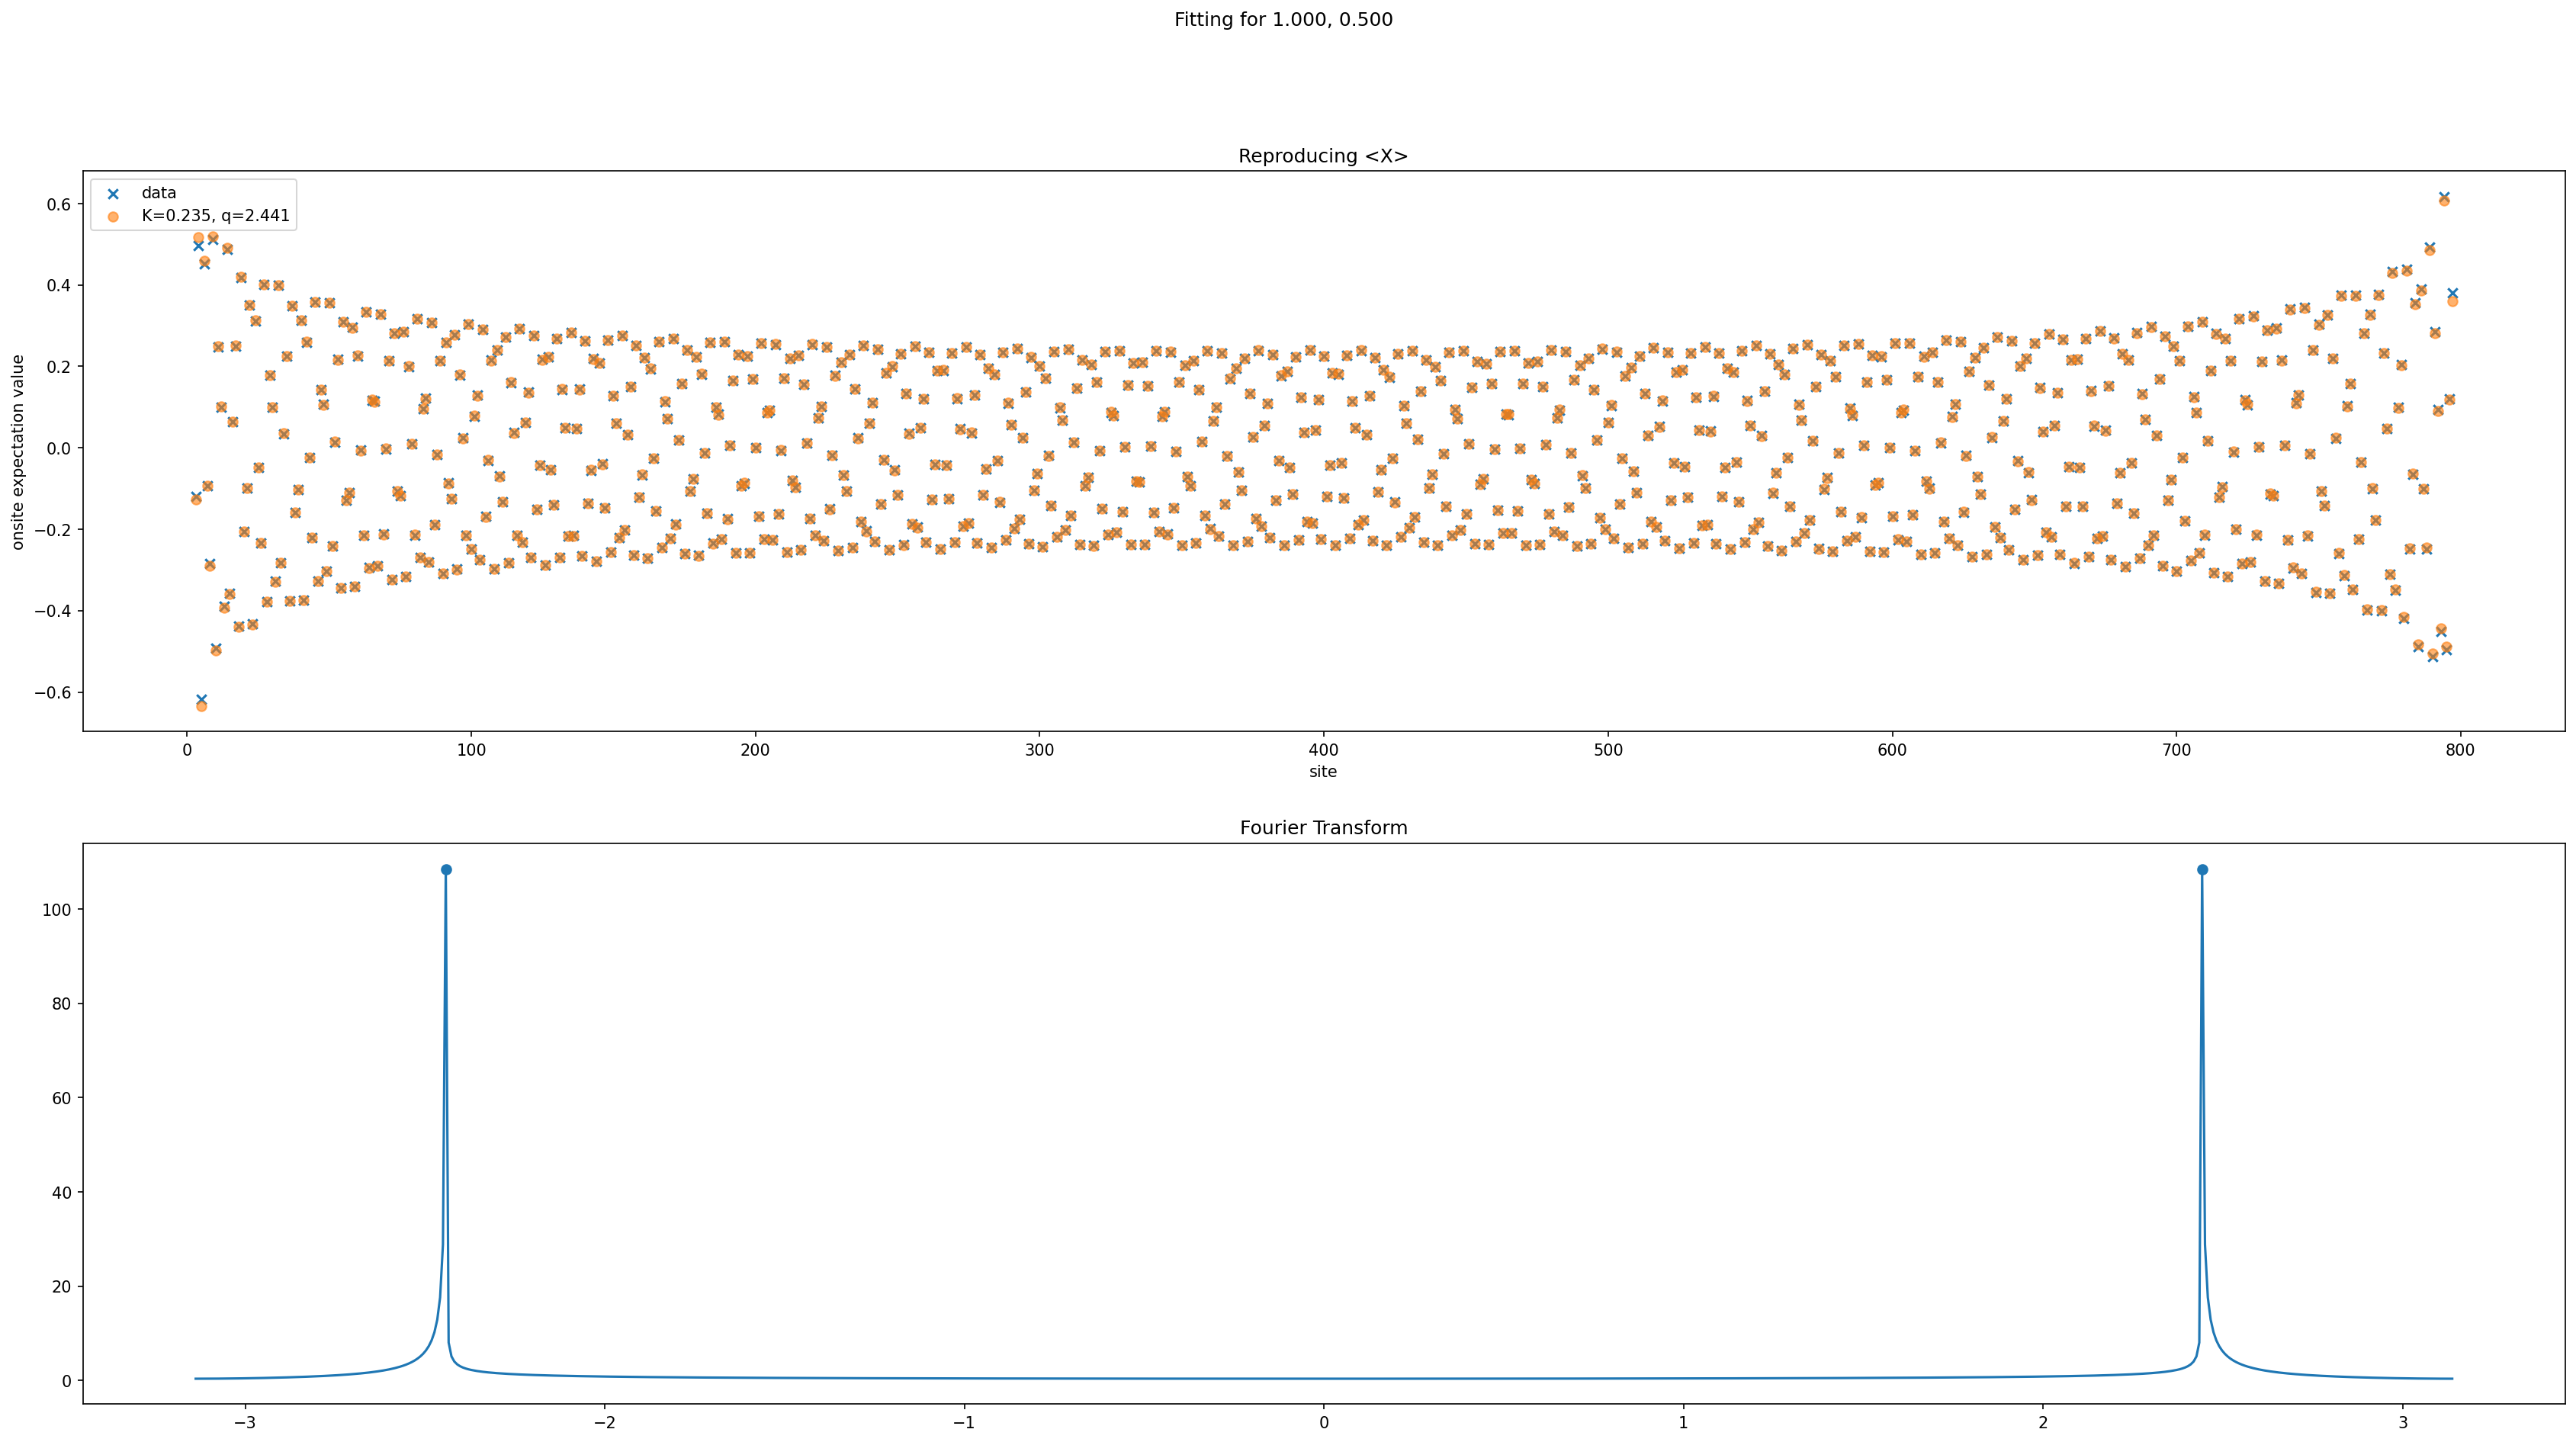

 67%|██████▋   | 4/6 [00:02<00:01,  1.34it/s]

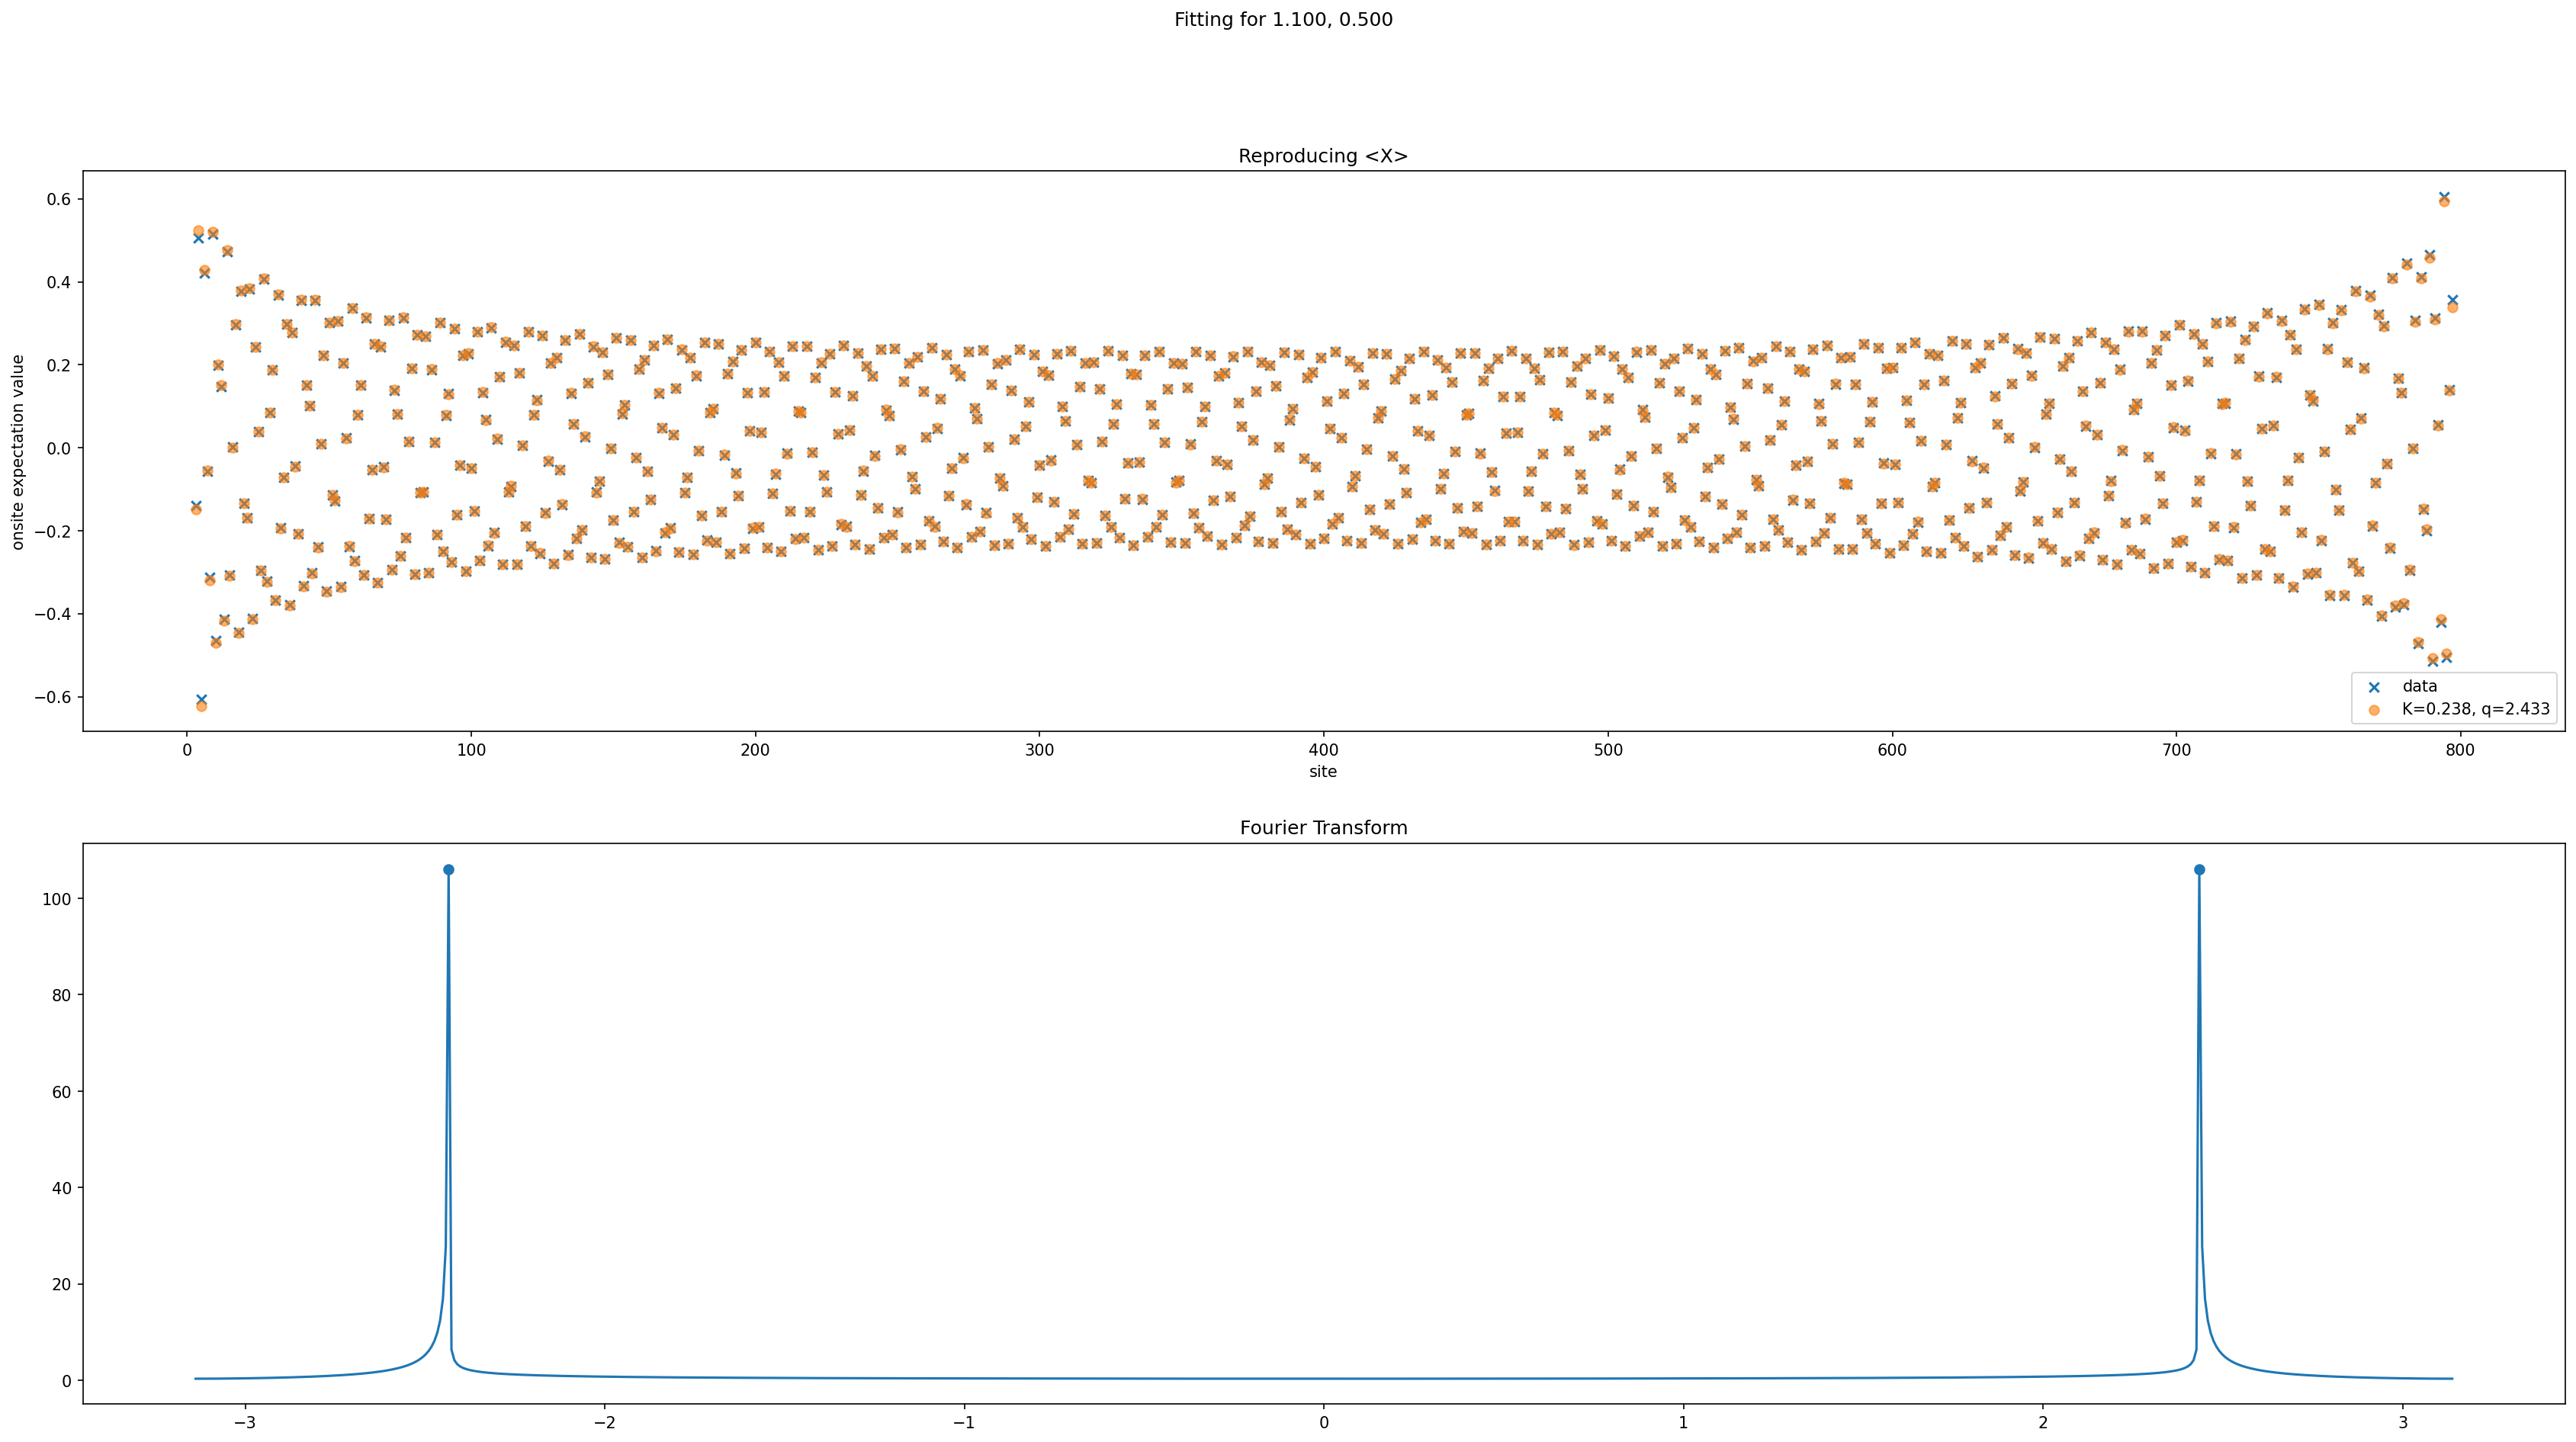

 83%|████████▎ | 5/6 [00:03<00:00,  1.38it/s]

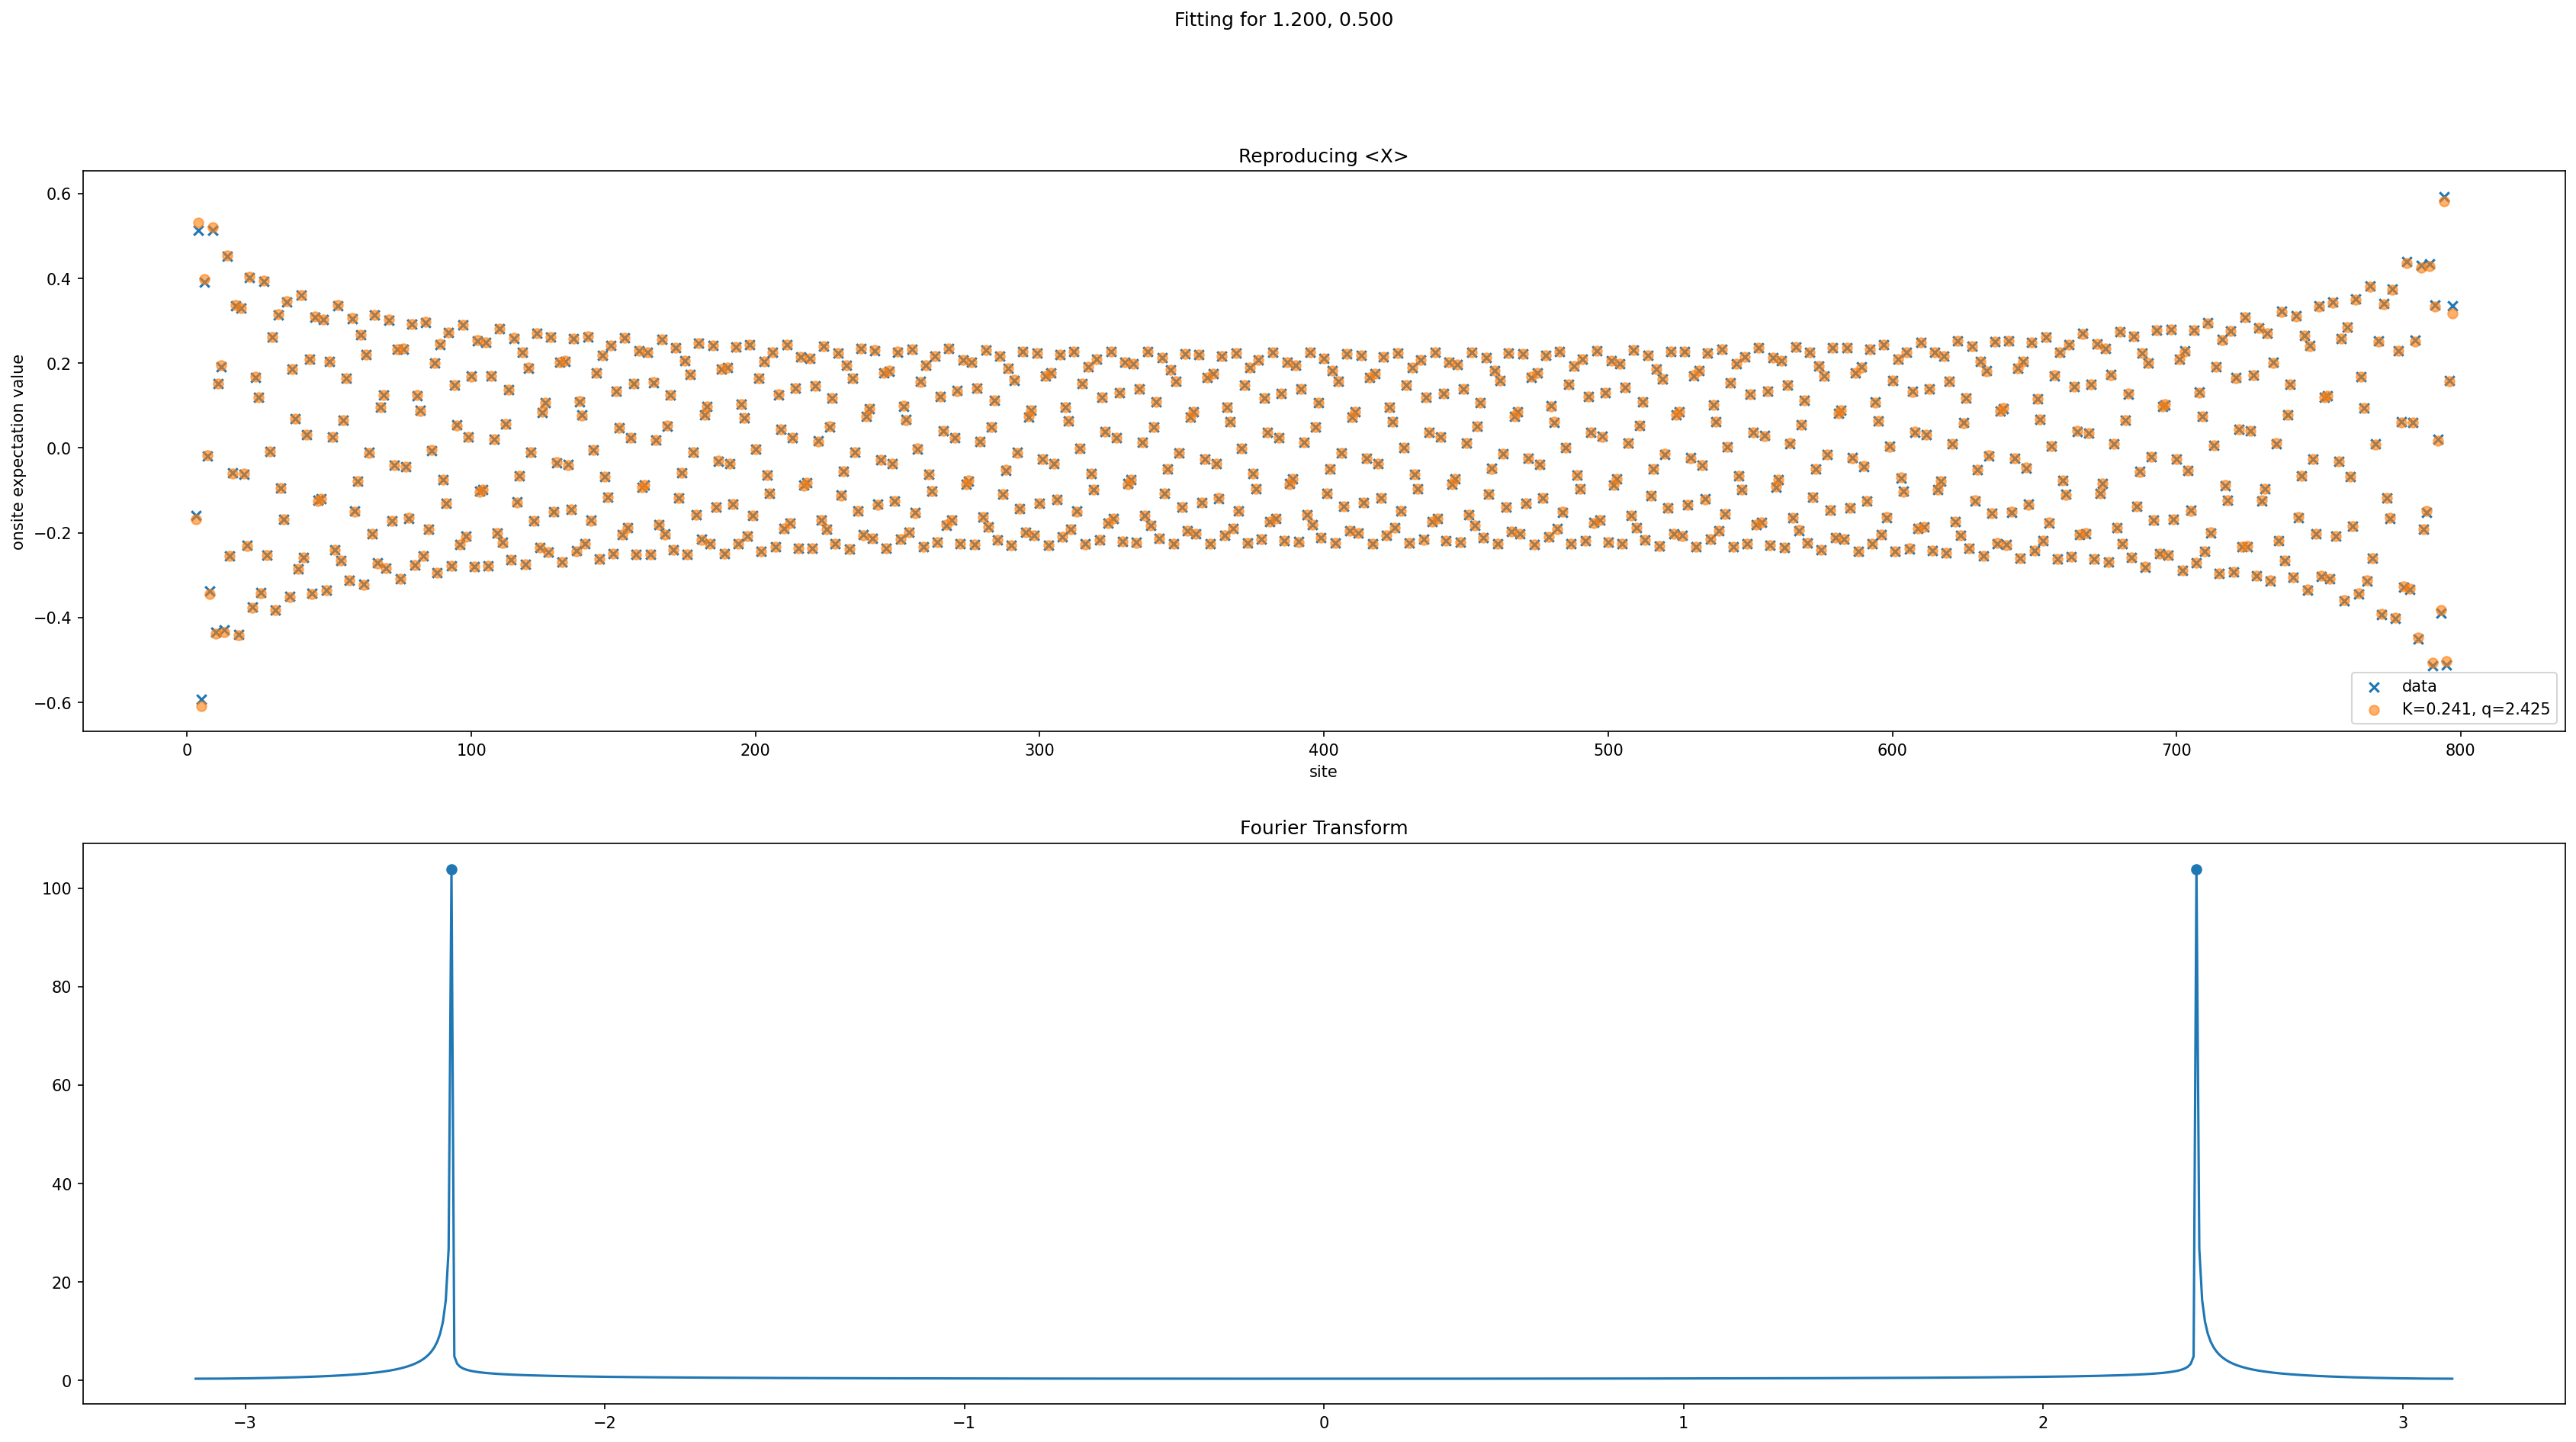

100%|██████████| 6/6 [00:04<00:00,  1.33it/s]


In [21]:
plotting = True

params = []
K_vals = []
q_vals = []
q_fft = []
phi_vals = []

for i in tqdm(sorted(os.listdir(results))):

    loc = os.path.join(results, i)
    x, X = np.loadtxt(os.path.join(loc, "X.txt")).T

    valid = (x > 2) & (x < (L - 2))
    x = x[valid]
    X = X[valid]

    h, k = i.split("_")
    h = h[1:]

    def find_K(x, X):
        def envelope(site, A, K):
            return A / (((L/np.pi) * np.sin(np.pi * site / L))**K)

        popt_K, pcov_K = curve_fit(envelope, x, np.abs(X), p0=[1, 1])
        return popt_K
    
    def find_q(x, X, K):
        envelope_factor = ((L/np.pi) * np.sin(np.pi * x / L))**K
        X_flat = X * envelope_factor

        # take initial guess with fourier transform
        X_fft = np.fft.fftshift(np.fft.fft(X_flat))
        freqs = np.fft.fftshift(np.fft.fftfreq(len(X_flat), d=1)) * 2*np.pi

        idx = np.argmax(np.abs(X_fft))
        q_guess = np.abs(freqs[idx])

        # fit oscillations
        def oscillation(site, A, q, phi):
            return A * np.cos(q * site + phi)

        popt_q, pcov_q = curve_fit(oscillation, x, X_flat, p0=[1, q_guess, 0], maxfev=10000)
        return popt_q

    A_env, K = find_K(x, X)
    A_fit, q_fit, phi_fit = find_q(x, X, K)

    def friedel(site, A, q, phi, K):
        return A * np.cos(q * site + phi) / (
            ((L/np.pi) * np.sin(np.pi * site / L))**K
        )

    popt, pcov = curve_fit(friedel, x, X, p0 = [A_fit, q_fit, phi_fit, K])
    X_model = friedel(x, *popt)

    # reproduce fourier transform for plot
    X_fft_orig = np.fft.fftshift(np.fft.fft(X))
    freqs_orig = np.fft.fftshift(np.fft.fftfreq(len(X), d=1)) * 2*np.pi

    peak_inds, _ = scipy.signal.find_peaks(np.abs(X_fft_orig))

    if len(peak_inds) > 0:
        leader = freqs_orig[peak_inds[np.argmax(np.abs(X_fft_orig[peak_inds]))]]
    else:
        leader = np.pi

    # save results
    params.append([float(h), float(k)])
    K_vals.append(K)
    q_vals.append(q_fit)
    phi_vals.append(phi_fit)
    q_fft.append(leader)

    if plotting:
        fig, ax = plt.subplots(2, 1, figsize=(28, 14))
        fig.suptitle(f"Fitting for {h}, {k}")

        ax[0].set_title("Reproducing <X>")
        ax[0].scatter(x, X, marker="x", label="data")
        ax[0].scatter(x, X_model, marker='o', alpha=0.6, label=f"K={K:.3f}, q={q_fit:.3f}")
        ax[0].legend()

        ax[1].set_title("Fourier Transform")
        ax[1].plot(freqs_orig, np.abs(X_fft_orig))
        ax[1].scatter(freqs_orig[peak_inds], np.abs(X_fft_orig[peak_inds]))

        ax[0].set_xlabel("site")
        ax[0].set_ylabel("onsite expectation value")
        plt.show()

[2.46585 2.45795 2.45005 2.44214 2.43424 2.42634]


/tmp/ipykernel_118456/4241898546.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()


Text(0.5, 1.0, 'Wavevector q')

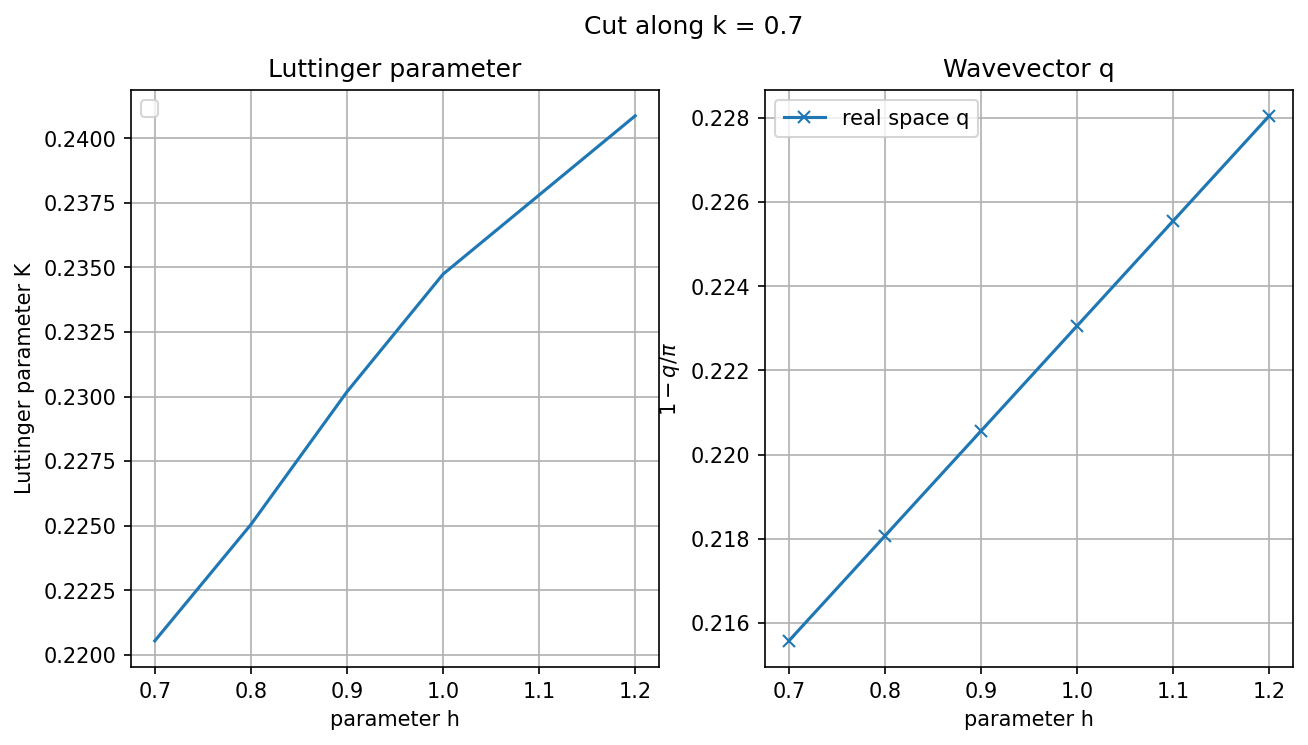

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
q_fft_copy = q_fft
# for i in range(10):
#     q_fft_copy[i] = 1
k, h = np.array(params).T
red_line=0.2
print(np.abs(q_fft))
fig.suptitle(f"Cut along k = {k[0]}") 
ax[0].plot(k, K_vals)
ax[0].grid()
ax[0].legend()
ax[0].set_xlabel("parameter h")
ax[0].set_ylabel("Luttinger parameter K")
ax[0].set_title(f"Luttinger parameter")

ax[1].plot(k, 1- np.array(q_vals)/np.pi, marker="x",label="real space q")
# ax[1].scatter(h, 1-np.array(np.abs(q_fft))/np.pi, alpha=0.6, label="Fourier transform")
ax[1].grid()
ax[1].legend()
ax[1].set_xlabel("parameter h")
ax[1].set_ylabel(r"$1 - q / \pi$")
ax[1].set_title(f"Wavevector q")

/tmp/ipykernel_118456/3689039263.py:6: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(lin, h_arr[4:11], (np.pi-q_arr[4:11])**2)


Text(0.5, 1.0, 'Linear fit of $q^2 \\propto |k-k_c|$ for $k > k_c$. Error of fit:inf, inf')

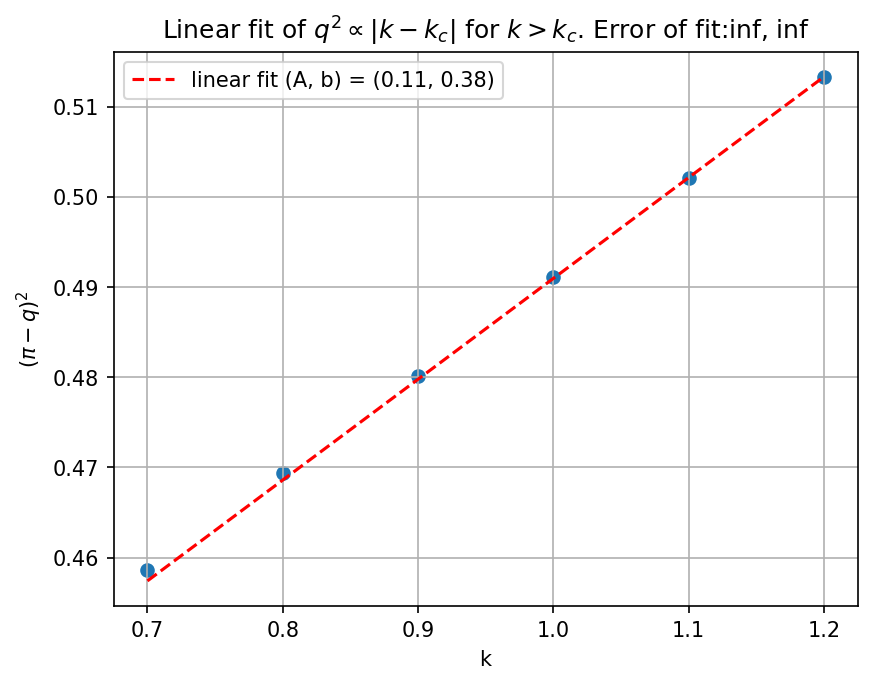

In [23]:
def lin(x,a,b):
    return a*x+b
h_arr = np.array(k, dtype=float)
q_arr = np.array(q_vals, dtype=float)
plt.scatter(h_arr, (np.pi-q_arr)**2)
popt, pcov = curve_fit(lin, h_arr[4:11], (np.pi-q_arr[4:11])**2)
# A, b = np.polyfit(h_arr[4:9], (np.pi-q_arr[4:9])**2, 1)
plt.plot(h_arr, popt[0]*h_arr+popt[1], ls="--", c="red", label=f"linear fit (A, b) = ({popt[0]:.2f}, {popt[1]:.2f})")
plt.xlabel("k")
plt.ylabel(r"$(\pi - q)^2$")
plt.legend()
plt.grid()
plt.title(r"Linear fit of $q^2 \propto |k-k_c|$ for $k > k_c$. Error of fit:" + f"{np.log10(np.abs(pcov[0][0]/popt[0]))}, {np.log10(np.abs(pcov[1][1]/popt[1]))}")

## Correlation Functions

100%|██████████| 6/6 [00:00<00:00, 37.14it/s]


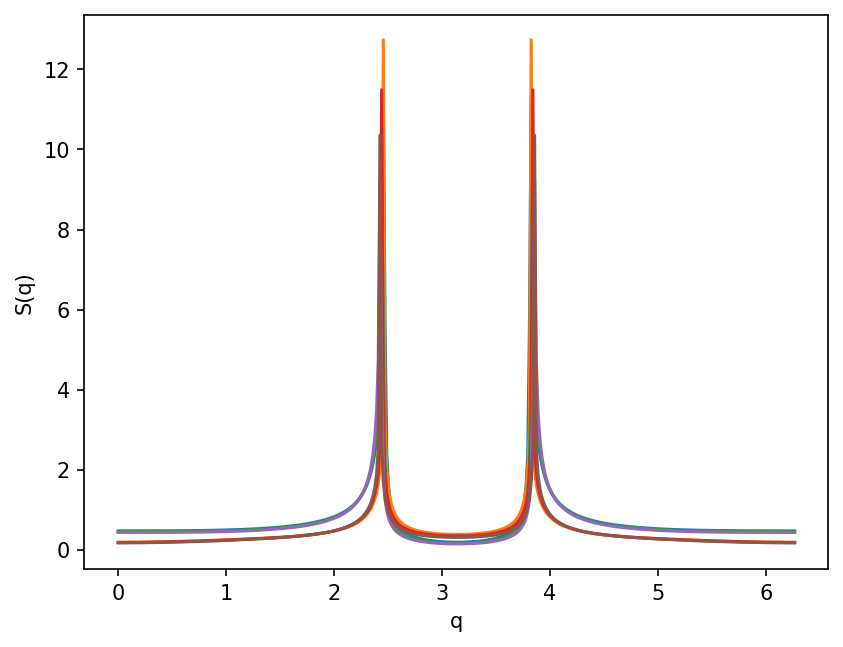

[]


In [25]:
# correlation functions
from tqdm import tqdm
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

def linfun_loglog(x, A, b):
    return np.exp(b) * (x**-A)
def linfun_semilogy(x, A, B):
    return B * np.exp(-x/A)

eta = []
ks = []

for i in tqdm(sorted(os.listdir(results))):
    loc = os.path.join(results, i)
    h, k = i.split("_")
    h = h[1:]

    _, op0 = np.loadtxt(os.path.join(loc, "X.txt")).T
    _, op1 = np.loadtxt(os.path.join(loc, "X.txt")).T

    j, corr = np.loadtxt(os.path.join(loc ,"XX_corr.txt")).T

    L = len(corr)
    qs = 2*np.pi*np.arange(L)/L

    Sq = np.zeros(L, dtype=complex)

    for qi,q in enumerate(qs):
        Sq[qi] = np.sum(corr * np.exp(1j*q*j))
        
    Sq = np.real(Sq)

    plt.plot(qs, np.abs(Sq))
    plt.xlabel("q")
    plt.ylabel("S(q)")
plt.show()

    # i0 = L // 2
    # corr -= op0[i0] * op1[i0+1 + j.astype(int)]    
    # plt.scatter(j, np.abs(corr))

    # peaks, _ = find_peaks(np.abs(corr))
    # if len(peaks) > 0:
    #     size_bool = (np.array(j)[peaks] < L//3)
    #     dx_peaks = np.array(j)[peaks][size_bool]
    #     corr_peaks = np.array(corr)[peaks][size_bool]
    #     # plt.scatter(dx_peaks, corr_peaks)
    # remove_noise = corr > 5e-12

    # popt, pcov = curve_fit(linfun_semilogy, j[:8], np.abs(corr[:8]))
    # # plt.plot(j, linfun_semilogy(j, *popt))
    # plt.legend()
    # plt.loglog()
    # plt.title(f"({h}, {k})")
    # eta.append(popt[0])
    # ks.append(float(h))

    # plt.show()
print(eta)



0.4920049829389171
0.4888346563410832
0.48543354869235955
0.48179625904640433
0.4779170972787292


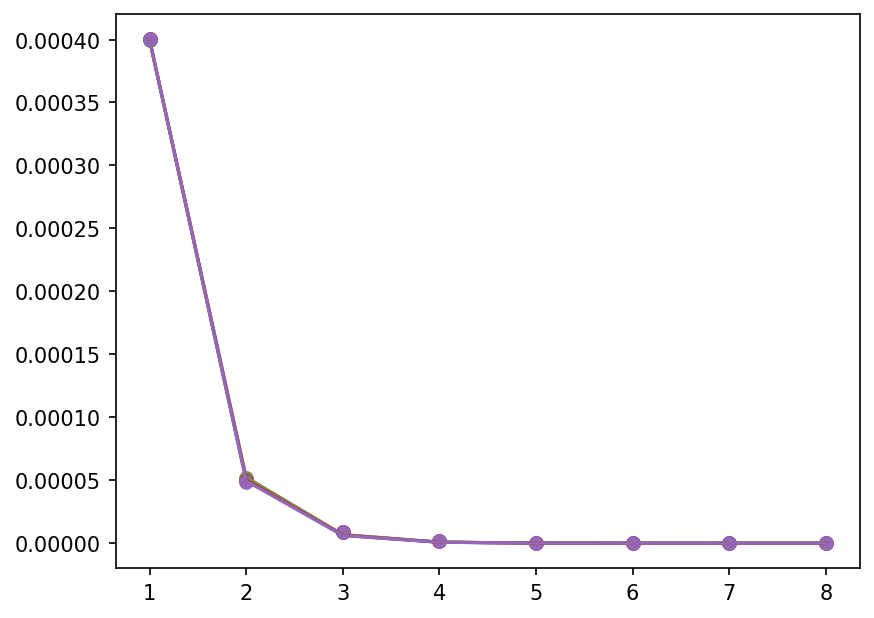

In [77]:
def exp_decay(r, A0, xi):
    return A0 * np.exp(-r / xi)

xxx = []
for folder in sorted(os.listdir(results))[:5]:
    loc = os.path.join(results, folder)
    h, k = folder.split("_")
    h = float(h[1:])
    k = float(k)

    _, op = np.loadtxt(os.path.join(loc, "X.txt")).T
    r, corr = np.loadtxt(os.path.join(loc, "XX_corr.txt")).T
    r = r.astype(int)

    i0 = L // 2

    # check your file convention carefully here
    corr_conn = corr - op[i0] * op[i0+ 1 + r]

    mask = (r >= 1) & (r <= 8) & (np.abs(corr_conn) > 1e-11)

    if np.sum(mask) >= 4:
        popt, _ = curve_fit(
            exp_decay,
            r[mask],
            np.abs(corr_conn)[mask],
            p0=(np.abs(corr_conn[mask][0]), 2.0),
            bounds=([0.0, 0.0], [np.inf, np.inf]),
        )
        A0, xi = popt
        xxx.append(xi)
        plt.scatter(r[mask], np.abs(corr_conn)[mask])
        plt.plot(r[mask], exp_decay(r[mask], *popt), label=f"xi={xi:.2f}")
    print(xi)

[np.float64(0.4920049829389171), np.float64(0.4888346563410832), np.float64(0.48543354869235955), np.float64(0.48179625904640433), np.float64(0.4779170972787292)]


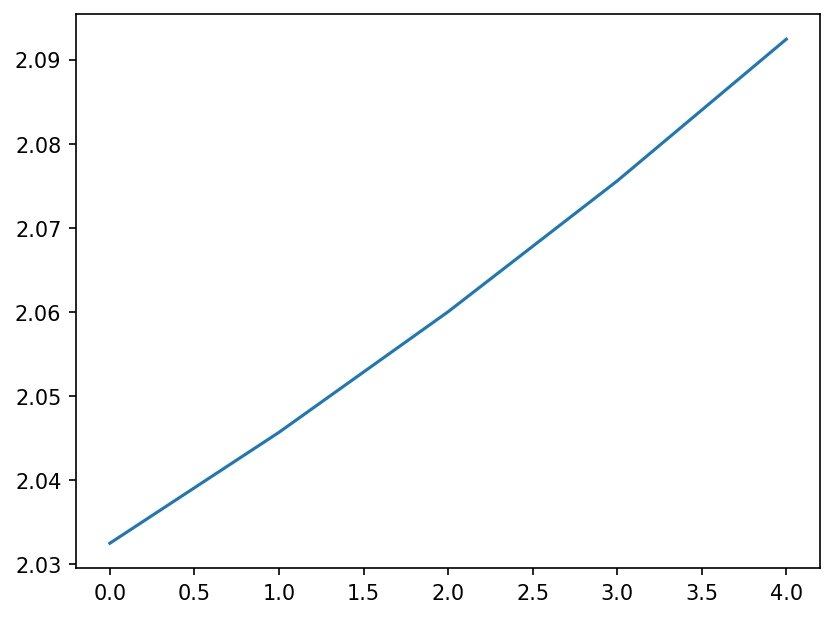

In [83]:
print(xxx)
plt.plot(np.array(xxx)**-1)


## Entanglement Entropy

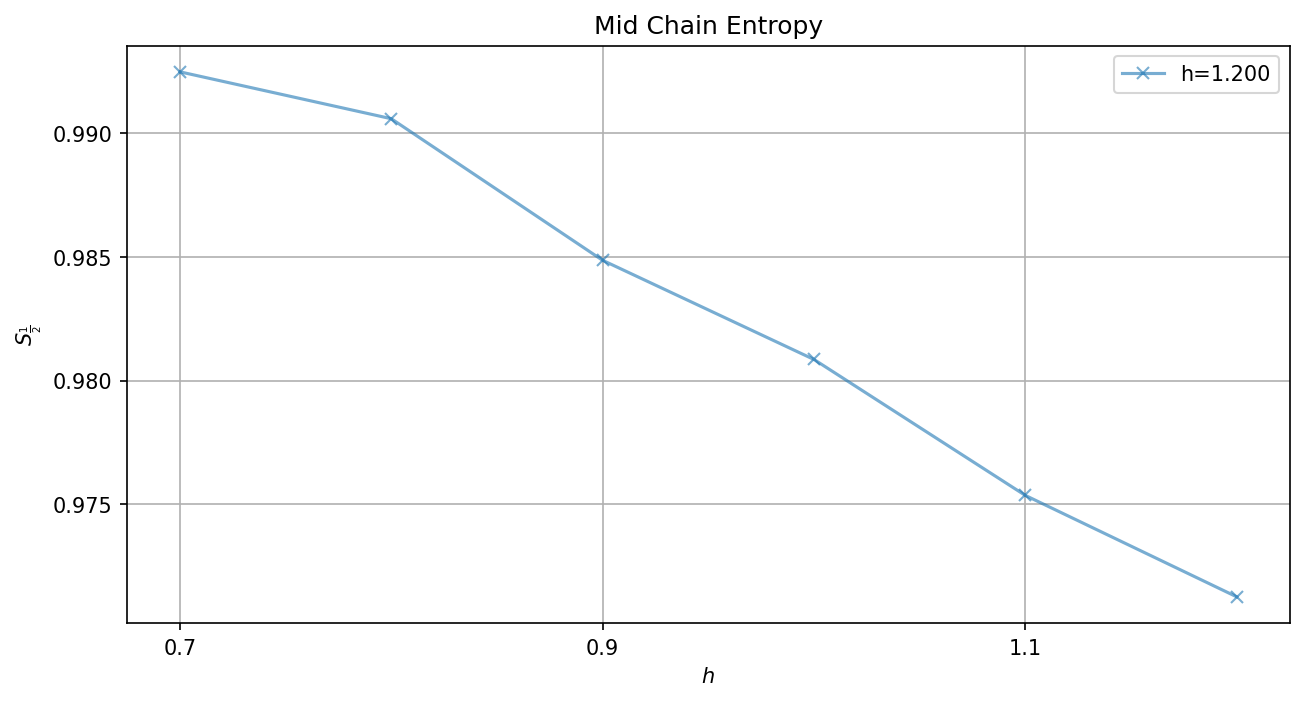

In [26]:
plt.figure(figsize=(10,5))

mid_chain_entropy = []
ks = []
for i in sorted(os.listdir(results)):
    loc = os.path.join(results, i)
    h, k = i.split("_")
    h = h[1:]
    x, _, S = np.loadtxt(os.path.join(loc, "S.txt")).T

    ks.append(float(h))
    mid_chain_entropy.append(S[L//2])
plt.plot(ks,mid_chain_entropy, marker="x", alpha=0.6, label=f"h={h}")
plt.xticks(ks[::2])

plt.title("Mid Chain Entropy")
plt.ylabel(r"$S_{\frac{1}{2}}$")
plt.xlabel(r"$h$")
plt.legend()
plt.grid()
plt.show()

800 [400. 401. 402. 403. 404. 405. 406. 407. 408. 409. 410. 411. 412. 413. 414. 415. 416. 417. 418.
 419. 420. 421. 422. 423. 424. 425. 426. 427. 428. 429. 430. 431. 432. 433. 434. 435. 436. 437.
 438. 439. 440. 441. 442. 443. 444. 445. 446. 447. 448. 449. 450. 451. 452. 453. 454. 455. 456.
 457. 458. 459. 460. 461. 462. 463. 464. 465. 466. 467. 468. 469. 470. 471. 472. 473. 474. 475.
 476. 477. 478. 479. 480. 481. 482. 483. 484. 485. 486. 487. 488. 489. 490. 491. 492. 493. 494.
 495. 496. 497. 498. 499. 500. 501. 502. 503. 504. 505. 506. 507. 508. 509. 510. 511. 512. 513.
 514. 515. 516. 517. 518. 519. 520. 521. 522. 523. 524. 525. 526. 527. 528. 529. 530. 531. 532.
 533. 534. 535. 536. 537. 538. 539. 540. 541. 542. 543. 544. 545. 546. 547. 548. 549. 550. 551.
 552. 553. 554. 555. 556. 557. 558. 559. 560. 561. 562. 563. 564. 565. 566. 567. 568. 569. 570.
 571. 572. 573. 574. 575. 576. 577. 578. 579. 580. 581. 582. 583. 584. 585. 586. 587. 588. 589.
 590. 591. 592. 593. 594. 595. 596. 

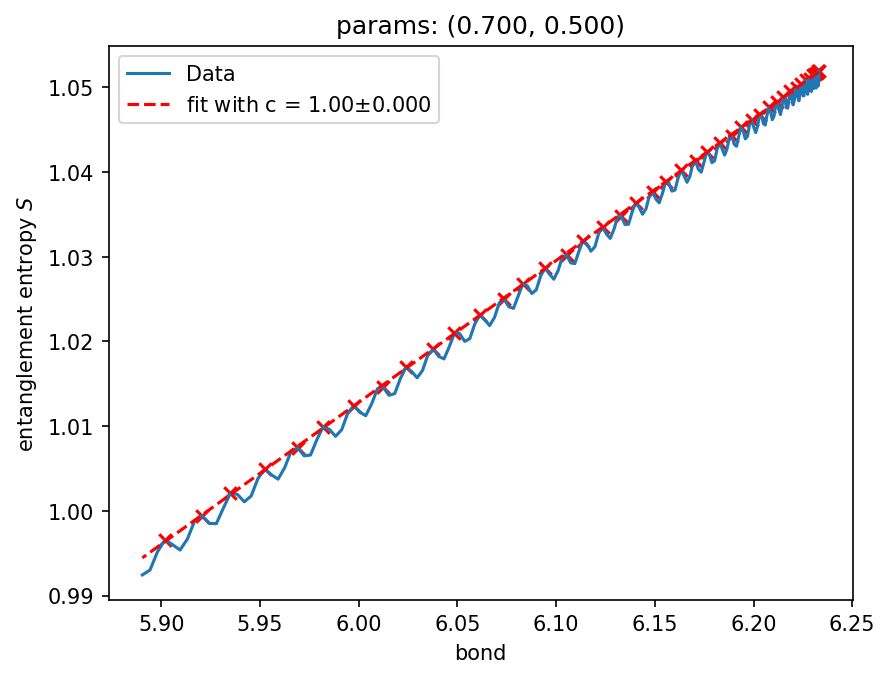

800 [400. 401. 402. 403. 404. 405. 406. 407. 408. 409. 410. 411. 412. 413. 414. 415. 416. 417. 418.
 419. 420. 421. 422. 423. 424. 425. 426. 427. 428. 429. 430. 431. 432. 433. 434. 435. 436. 437.
 438. 439. 440. 441. 442. 443. 444. 445. 446. 447. 448. 449. 450. 451. 452. 453. 454. 455. 456.
 457. 458. 459. 460. 461. 462. 463. 464. 465. 466. 467. 468. 469. 470. 471. 472. 473. 474. 475.
 476. 477. 478. 479. 480. 481. 482. 483. 484. 485. 486. 487. 488. 489. 490. 491. 492. 493. 494.
 495. 496. 497. 498. 499. 500. 501. 502. 503. 504. 505. 506. 507. 508. 509. 510. 511. 512. 513.
 514. 515. 516. 517. 518. 519. 520. 521. 522. 523. 524. 525. 526. 527. 528. 529. 530. 531. 532.
 533. 534. 535. 536. 537. 538. 539. 540. 541. 542. 543. 544. 545. 546. 547. 548. 549. 550. 551.
 552. 553. 554. 555. 556. 557. 558. 559. 560. 561. 562. 563. 564. 565. 566. 567. 568. 569. 570.
 571. 572. 573. 574. 575. 576. 577. 578. 579. 580. 581. 582. 583. 584. 585. 586. 587. 588. 589.
 590. 591. 592. 593. 594. 595. 596. 

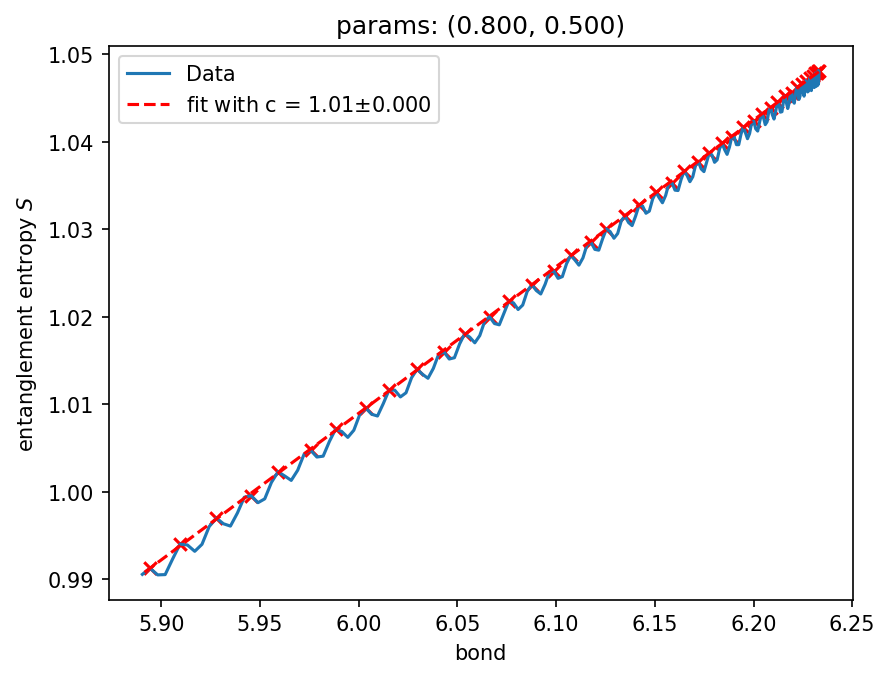

800 [400. 401. 402. 403. 404. 405. 406. 407. 408. 409. 410. 411. 412. 413. 414. 415. 416. 417. 418.
 419. 420. 421. 422. 423. 424. 425. 426. 427. 428. 429. 430. 431. 432. 433. 434. 435. 436. 437.
 438. 439. 440. 441. 442. 443. 444. 445. 446. 447. 448. 449. 450. 451. 452. 453. 454. 455. 456.
 457. 458. 459. 460. 461. 462. 463. 464. 465. 466. 467. 468. 469. 470. 471. 472. 473. 474. 475.
 476. 477. 478. 479. 480. 481. 482. 483. 484. 485. 486. 487. 488. 489. 490. 491. 492. 493. 494.
 495. 496. 497. 498. 499. 500. 501. 502. 503. 504. 505. 506. 507. 508. 509. 510. 511. 512. 513.
 514. 515. 516. 517. 518. 519. 520. 521. 522. 523. 524. 525. 526. 527. 528. 529. 530. 531. 532.
 533. 534. 535. 536. 537. 538. 539. 540. 541. 542. 543. 544. 545. 546. 547. 548. 549. 550. 551.
 552. 553. 554. 555. 556. 557. 558. 559. 560. 561. 562. 563. 564. 565. 566. 567. 568. 569. 570.
 571. 572. 573. 574. 575. 576. 577. 578. 579. 580. 581. 582. 583. 584. 585. 586. 587. 588. 589.
 590. 591. 592. 593. 594. 595. 596. 

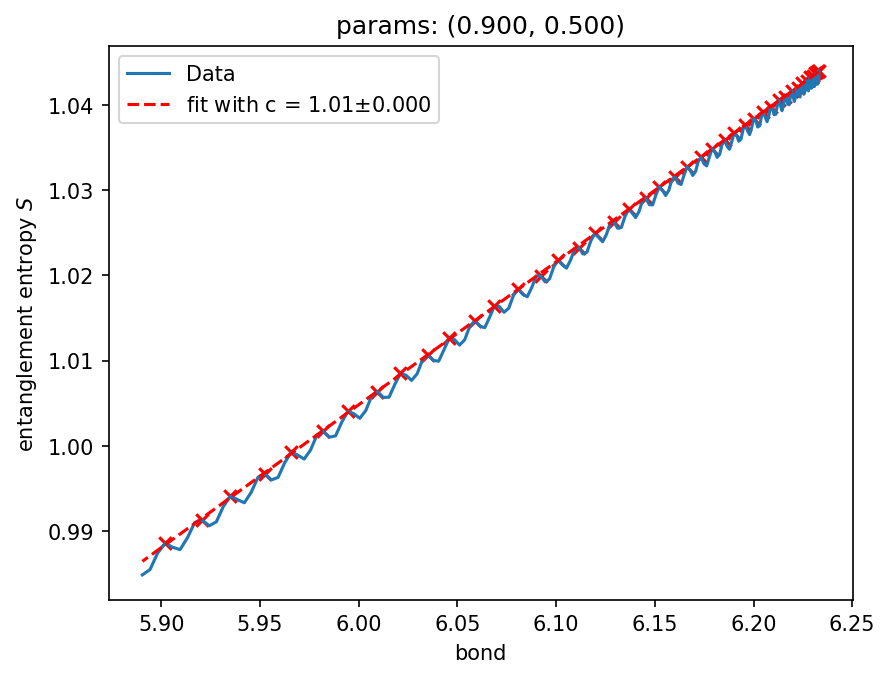

800 [400. 401. 402. 403. 404. 405. 406. 407. 408. 409. 410. 411. 412. 413. 414. 415. 416. 417. 418.
 419. 420. 421. 422. 423. 424. 425. 426. 427. 428. 429. 430. 431. 432. 433. 434. 435. 436. 437.
 438. 439. 440. 441. 442. 443. 444. 445. 446. 447. 448. 449. 450. 451. 452. 453. 454. 455. 456.
 457. 458. 459. 460. 461. 462. 463. 464. 465. 466. 467. 468. 469. 470. 471. 472. 473. 474. 475.
 476. 477. 478. 479. 480. 481. 482. 483. 484. 485. 486. 487. 488. 489. 490. 491. 492. 493. 494.
 495. 496. 497. 498. 499. 500. 501. 502. 503. 504. 505. 506. 507. 508. 509. 510. 511. 512. 513.
 514. 515. 516. 517. 518. 519. 520. 521. 522. 523. 524. 525. 526. 527. 528. 529. 530. 531. 532.
 533. 534. 535. 536. 537. 538. 539. 540. 541. 542. 543. 544. 545. 546. 547. 548. 549. 550. 551.
 552. 553. 554. 555. 556. 557. 558. 559. 560. 561. 562. 563. 564. 565. 566. 567. 568. 569. 570.
 571. 572. 573. 574. 575. 576. 577. 578. 579. 580. 581. 582. 583. 584. 585. 586. 587. 588. 589.
 590. 591. 592. 593. 594. 595. 596. 

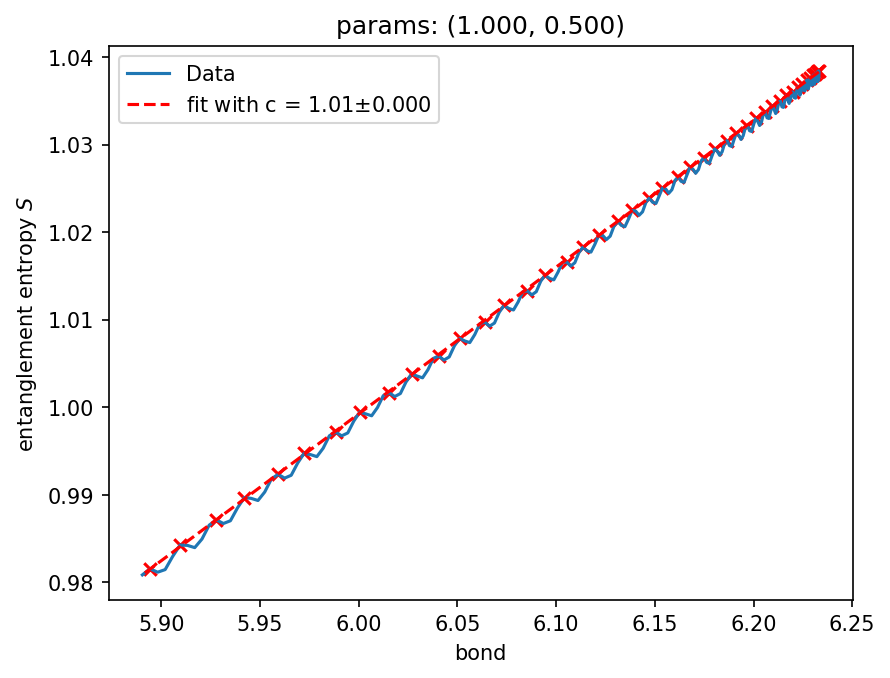

800 [400. 401. 402. 403. 404. 405. 406. 407. 408. 409. 410. 411. 412. 413. 414. 415. 416. 417. 418.
 419. 420. 421. 422. 423. 424. 425. 426. 427. 428. 429. 430. 431. 432. 433. 434. 435. 436. 437.
 438. 439. 440. 441. 442. 443. 444. 445. 446. 447. 448. 449. 450. 451. 452. 453. 454. 455. 456.
 457. 458. 459. 460. 461. 462. 463. 464. 465. 466. 467. 468. 469. 470. 471. 472. 473. 474. 475.
 476. 477. 478. 479. 480. 481. 482. 483. 484. 485. 486. 487. 488. 489. 490. 491. 492. 493. 494.
 495. 496. 497. 498. 499. 500. 501. 502. 503. 504. 505. 506. 507. 508. 509. 510. 511. 512. 513.
 514. 515. 516. 517. 518. 519. 520. 521. 522. 523. 524. 525. 526. 527. 528. 529. 530. 531. 532.
 533. 534. 535. 536. 537. 538. 539. 540. 541. 542. 543. 544. 545. 546. 547. 548. 549. 550. 551.
 552. 553. 554. 555. 556. 557. 558. 559. 560. 561. 562. 563. 564. 565. 566. 567. 568. 569. 570.
 571. 572. 573. 574. 575. 576. 577. 578. 579. 580. 581. 582. 583. 584. 585. 586. 587. 588. 589.
 590. 591. 592. 593. 594. 595. 596. 

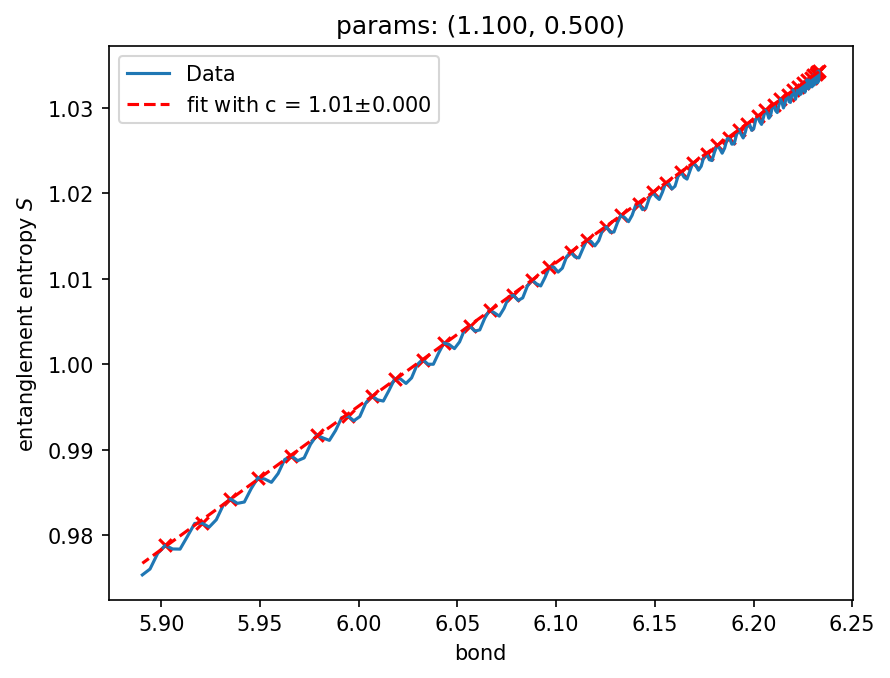

800 [400. 401. 402. 403. 404. 405. 406. 407. 408. 409. 410. 411. 412. 413. 414. 415. 416. 417. 418.
 419. 420. 421. 422. 423. 424. 425. 426. 427. 428. 429. 430. 431. 432. 433. 434. 435. 436. 437.
 438. 439. 440. 441. 442. 443. 444. 445. 446. 447. 448. 449. 450. 451. 452. 453. 454. 455. 456.
 457. 458. 459. 460. 461. 462. 463. 464. 465. 466. 467. 468. 469. 470. 471. 472. 473. 474. 475.
 476. 477. 478. 479. 480. 481. 482. 483. 484. 485. 486. 487. 488. 489. 490. 491. 492. 493. 494.
 495. 496. 497. 498. 499. 500. 501. 502. 503. 504. 505. 506. 507. 508. 509. 510. 511. 512. 513.
 514. 515. 516. 517. 518. 519. 520. 521. 522. 523. 524. 525. 526. 527. 528. 529. 530. 531. 532.
 533. 534. 535. 536. 537. 538. 539. 540. 541. 542. 543. 544. 545. 546. 547. 548. 549. 550. 551.
 552. 553. 554. 555. 556. 557. 558. 559. 560. 561. 562. 563. 564. 565. 566. 567. 568. 569. 570.
 571. 572. 573. 574. 575. 576. 577. 578. 579. 580. 581. 582. 583. 584. 585. 586. 587. 588. 589.
 590. 591. 592. 593. 594. 595. 596. 

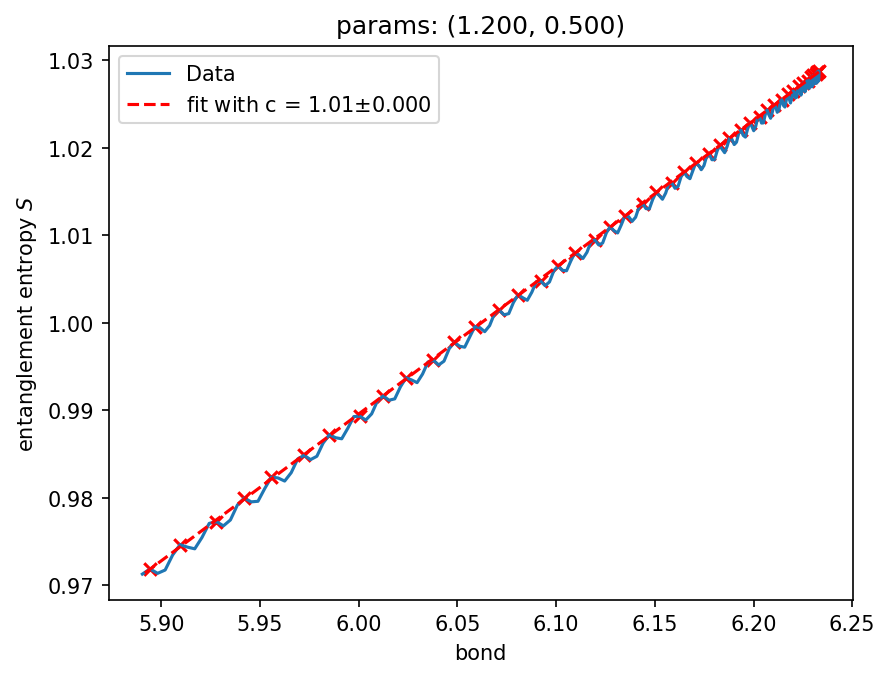

(6, 2)


In [37]:
def linfun(x, c, consta):
    return (c/6) * x + consta

def conformal_distance(L, pos):
    print(L, pos)
    return np.log((2*L/(np.pi) * np.sin((np.pi*pos)/L)))

c = []
c_err=[]
ks = np.zeros((len(os.listdir(results)), 2))

for index, i in enumerate(sorted(os.listdir(results))):
    h = i.split('_')[0][1:]
    k = i.split("_")[-1]
    loc = os.path.join(results, i)

    x, _, S = np.loadtxt(os.path.join(loc, "S.txt")).T
    L = 800
    cut = 3*L//4
    conformal_bonds   = conformal_distance(L, x[L//2:cut])
    conformal_entropy = S[L//2:cut]
    
    peaks, _ = find_peaks(conformal_entropy)
    if len(conformal_entropy[peaks]) < 2:
        continue
    popt, pcov = curve_fit(linfun, conformal_bonds[peaks], conformal_entropy[peaks])

    # plt.scatter(bonds, S)

    # preform fit to extract the central charge

    plt.title(f"params: ({h}, {k})")
    plt.plot(conformal_bonds, conformal_entropy, label=f"Data")
    plt.scatter(conformal_bonds[peaks], conformal_entropy[peaks], color='red', marker='x')
    plt.plot(conformal_bonds, linfun(conformal_bonds, *popt), ls="--", c='red',label=f"fit with c = {popt[0]:.2f}"+r"$\pm$"+f"{pcov[0][0]:.3f}")
    plt.xlabel("bond")
    plt.ylabel("entanglement entropy $S$")
    plt.legend()
    plt.show()

    c.append(popt[0])
    c_err.append(pcov[0][0])
    ks[index] = [float(h), float(k)]

print(np.array(ks).shape)

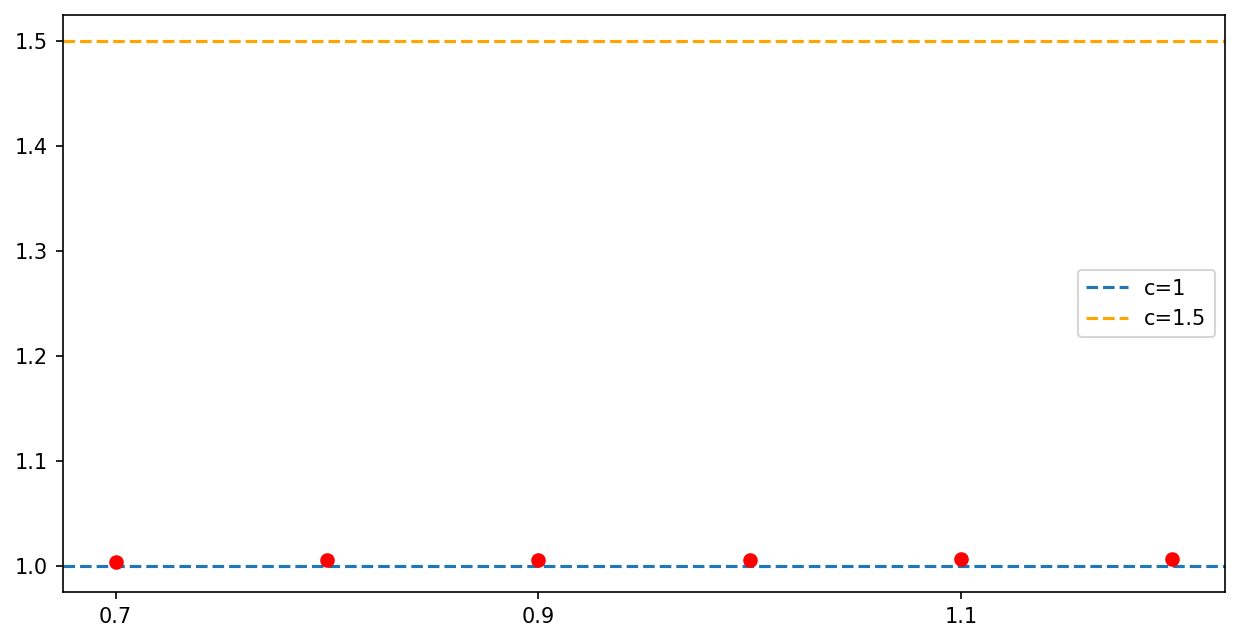

In [39]:
k, h =  np.array(ks).T

plt.figure(figsize=(10,5))

plt.errorbar(k, c, c_err, marker='o', c='red', ls="none")
plt.axhline(1, ls="--",label=f"c=1")
plt.axhline(1.5,ls="--",c='orange', label=f"c=1.5")
plt.xticks(k[::2])
plt.legend()
plt.show()

## Finding critical exponents

## Building the phase diagram

Use this to create python code for creating the big phase diagram at the end

Use plt.plot for the lines with marker for each point that you actually plotted
plt.fill_between for the colours

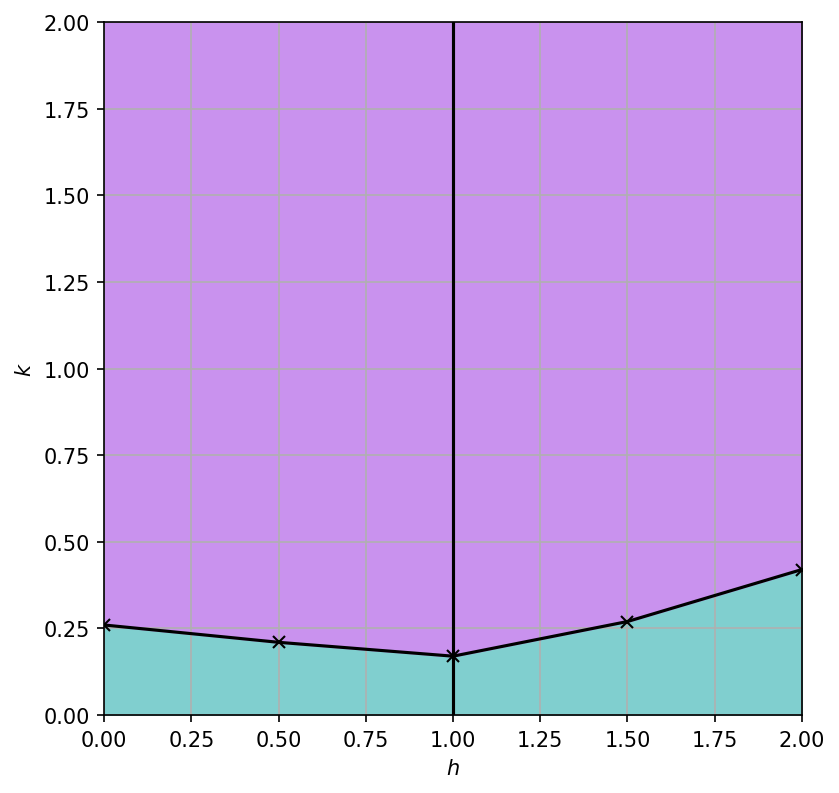

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(6, 6))

values = [0, 0.5, 1.0, 1.5, 2]
first_order_transition = [0.26, 0.21, 0.17, 0.27, 0.42]

# primary phase transitions
plt.plot(values, first_order_transition, c="black", marker='x')
# plt.plot(values_dual, first_order_transition_dual, c="black", marker="x")
plt.axvline(1, c="black")

# draw in phases
plt.fill_between(values, [0]*len(first_order_transition), first_order_transition, color="#7FCFCFFD")
# plt.fill_between(values_dual, [0]*len(first_order_transition_dual), first_order_transition_dual, color="#E68B41")
plt.fill_between(values, first_order_transition, [2]*len(first_order_transition), color="#C992EE")
# plt.fill_between(values_dual, first_order_transition_dual, [2]*len(first_order_transition_dual), color="#EE8585")
# plt.axhline(0.18)
# add labels to diagram

# control the location of things
plt.xlim(0, 2)
plt.ylim(0, 2)
plt.xlabel(r"$h$")
plt.ylabel(r"$k$")
# plt.xticks(np.arange(0.7, 1.3, 0.05))
plt.grid()
plt.show()

In [ ]:
h_x, k = 0, 0
hours, minutes, seconds = 0, 0, 0
E_temp = [0]
chi = 200

print(f'Parameter ({h_x:.3f}, {k:.3f}) done !!!\n'
        f'Time elapsed: {hours:02}:{minutes:02}:{seconds:02}\n'
        f'Final Energy: {E_temp[-1]}\n'
        f'Final bond dimension: {chi}\n')
print(f'Parameter ({h_x:.3f}, {k:.3f}) done !!!\n'
        f'Time elapsed: {hours:02}:{minutes:02}:{seconds:02}\n'
        f'Final Energy: {E_temp[-1]}\n'
        f'Final bond dimension: {chi}\n')

Parameter (0.000, 0.000) done !!!
Time elapsed: 00:00:00
Final Energy: 0
Final bond dimension: 200

Parameter (0.000, 0.000) done !!!
Time elapsed: 00:00:00
Final Energy: 0
Final bond dimension: 200



### Calculate lines of incommensurability

We want lines of incommensurability across the following values:
$$ h = [0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8], $$
$$ q = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]$$

In other words, we will have 6 lines of 9 points to determine the flow of incommensurability.

This means that we will need to send 9 simulations to the cluster of 0 < k < 3.


In [ ]:
# At the moment, just running 0.4, 0.8, 1.2, 1.6 ://
